# Bài tập 1 — Phân loại bệnh về mắt bằng các mô hình CNN

**Học viên:** Đặng Thành Nhân
**Môn học:** Deep Learning — Homework 1

---

## 1. Đề bài

> Hãy thực hiện huấn luyện các mô hình CNN mà bạn biết để phân loại các bệnh về mắt.
> Dataset như link bên dưới: <https://www.nature.com/articles/s41597-026-07093-7>
> Chia các tập: train - validation - test theo tỉ lệ **7:1:2**.
> Phân tích kết quả đạt được trên mô hình có kết quả **tốt nhất** và **tệ nhất**.

## 2. Bộ dữ liệu

Link đề bài trỏ tới bài báo trên *Scientific Data* (Nature):

> **A fundus image dataset for intelligent diabetic retinopathy system**
> Peng, S., Zhao, X., Yang, S., Zhang, Y., Bai, Q., Lei, B., Zhang, G.
> *Scientific Data* **13**, 777 (2026). DOI: [10.1038/s41597-026-07093-7](https://doi.org/10.1038/s41597-026-07093-7)

Dữ liệu ảnh đi kèm bài báo được lưu trữ công khai trên **figshare**:

> Ultra-wide-field (SLO) fundus image dataset for intelligent diabetic retinopathy system.
> figshare. DOI: [10.6084/m9.figshare.31259494](https://doi.org/10.6084/m9.figshare.31259494) — giấy phép **CC BY 4.0**.
> File tải trực tiếp (~383 MB): <https://ndownloader.figshare.com/files/61650007>

**Mô tả dữ liệu (theo bài báo gốc):**

| Thuộc tính | Giá trị |
|---|---|
| Loại ảnh | Ultra-wide-field (UWF) SLO fundus — ảnh đáy mắt góc siêu rộng |
| Tổng số ảnh | **1.630** ảnh, từ **809** bệnh nhân |
| Định dạng / kích thước | JPG, 512 × 512 pixel |
| Số lớp | **3** |
| Nhãn | `Normal` (0), `NPDR` (1 — bệnh võng mạc đái tháo đường chưa tăng sinh), `PDR` (2 — bệnh võng mạc đái tháo đường tăng sinh) |
| Gán nhãn | 3 bác sĩ nhãn khoa cao cấp đọc và thống nhất |

Phân bố ảnh theo từng lớp được công bố trong bài báo:

| Lớp | Train | Validation | Test | **Tổng** | Số bệnh nhân |
|---|---|---|---|---|---|
| Normal | 347 | 50 | 99 | **496** | 204 |
| NPDR | 444 | 63 | 127 | **634** | 344 |
| PDR | 350 | 50 | 100 | **500** | 261 |
| **Tổng** | 1.141 | 163 | 326 | **1.630** | 809 |

Cấu trúc thư mục sau khi giải nén (theo mục *Data Records* của bài báo): thư mục gốc
`diabetic retinopathy/` chứa 3 thư mục con `Normal/`, `NPDR/`, `PDR/` và 3 file bảng
`train.xls`, `validate.xls`, `test.xls` mô tả cách chia dữ liệu của tác giả.

> **Ghi chú quan trọng:** cách chia sẵn của tác giả (1141 / 163 / 326) đúng bằng tỉ lệ
> 70% / 10% / 20%. Tuy nhiên, để bám sát yêu cầu đề bài, notebook này **tự thực hiện lại**
> việc chia **7:1:2 có phân tầng (stratified), có seed cố định** trên toàn bộ 1.630 ảnh
> gộp lại, thay vì dùng file `.xls` có sẵn. Kết quả chia được in ra và `assert` để kiểm chứng.

> **Lưu ý về tính tổng quát:** phần nạp dữ liệu bên dưới được viết theo kiểu
> `ImageFolder` tổng quát — nó tự dò tìm các thư mục con chứa ảnh dưới `DATA_ROOT`.
> Vì vậy nếu thay bằng một bộ dữ liệu bệnh mắt khác có cùng cấu trúc
> `root/<tên_bệnh>/*.jpg` thì toàn bộ notebook vẫn chạy được mà không cần sửa code.

## 3. Nội dung notebook

1. Kiểm tra môi trường Colab (GPU, đĩa), mount Drive, seed
2. Tải & kiểm tra dữ liệu (hoàn toàn tự động, không cần thao tác tay)
3. EDA — phân bố lớp, ảnh mẫu, thống kê kích thước
4. Chia tập **7:1:2** phân tầng
5. Pipeline dữ liệu + augmentation
6. Xây dựng **5 mô hình CNN** (1 scratch + 4 transfer learning)
7. Huấn luyện chung một `train_model(...)`
8. Đánh giá trên test: accuracy, precision/recall/F1, confusion matrix, ROC-AUC
9. **Phân tích sâu mô hình tốt nhất & tệ nhất** (+ Grad-CAM)
10. Kết luận & đề xuất cải thiện

---
## 1. Chuẩn bị môi trường Colab

### 1.0. Bật GPU trước khi chạy

Nếu cell kiểm tra bên dưới báo **không có GPU**, hãy làm:

> **Runtime → Change runtime type → Hardware accelerator → GPU (T4)** → *Save* → *Runtime → Restart and run all*

Colab đã cài sẵn **torch (bản CUDA), torchvision, numpy, pandas, matplotlib, seaborn,
scikit-learn, scipy, Pillow, tqdm, requests, opencv, gdown, kagglehub**.
Vì vậy **không cài lại `torch`/`torchvision`** — vừa mất vài phút vừa có nguy cơ làm hỏng bản CUDA
đang hoạt động. Cell cài đặt bên dưới chỉ cài bù những gói còn thiếu (nếu có).

In [1]:
# --- Kiem tra phan cung & dung luong dia cua phien Colab ---
!nvidia-smi || echo "Khong co GPU: Runtime > Change runtime type > Hardware accelerator > GPU (T4)"
print()
!df -h /content | head -5

Tue Aug 25 06:31:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# --- Cai bu cac goi con thieu (Colab da co san hau het). Idempotent: co roi thi bo qua. ---
import importlib.util
import sys

# torch / torchvision KHONG cai lai - Colab da co san ban CUDA.
REQUIRED = {
    # ten_module : ten_goi_pip
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "PIL": "Pillow",
    "tqdm": "tqdm",
    "requests": "requests",
}

missing = []
for mod, pkg in REQUIRED.items():
    try:
        if importlib.util.find_spec(mod) is None:
            missing.append(pkg)
    except (ImportError, ValueError):
        missing.append(pkg)

if missing:
    print("Cai bu cac goi con thieu:", missing)
    get_ipython().system("pip install -q " + " ".join(missing))
else:
    print("[OK] Tat ca goi can thiet da co san - khong can cai them gi.")

# Kiem tra torch/torchvision co san (khong cai lai)
for mod in ["torch", "torchvision"]:
    ok = importlib.util.find_spec(mod) is not None
    print("{:<12}: {}".format(mod, "co san" if ok else "THIEU (bat thuong tren Colab)"))

[OK] Tat ca goi can thiet da co san - khong can cai them gi.
torch       : co san
torchvision : co san


In [3]:
# --- Imports & cau hinh hien thi ---
import hashlib
import json
import math
import os
import random
import shutil
import sys
import time
import warnings
import zipfile
from collections import Counter, OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from torchvision import models as tv_models
from torchvision import transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

print("python      :", sys.version.split()[0])
print("torch       :", torch.__version__)
print("torchvision :", torchvision.__version__)
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)

python      : 3.13.15
torch       : 2.11.0+cu128
torchvision : 0.26.0+cu128
numpy       : 2.1.3
pandas      : 2.2.3


In [4]:
# --- Phat hien GPU ---
CUDA_OK = torch.cuda.is_available()
DEVICE = torch.device("cuda" if CUDA_OK else "cpu")

print("torch.cuda.is_available :", CUDA_OK)
print("DEVICE                  :", DEVICE)

if CUDA_OK:
    props = torch.cuda.get_device_properties(0)
    VRAM_GB = props.total_memory / 1024 ** 3
    print("GPU                     :", props.name)
    print("VRAM                    : {:.1f} GB".format(VRAM_GB))
    print("CUDA runtime            :", torch.version.cuda)
    print("\n[OK] San sang huan luyen tren GPU.")
else:
    VRAM_GB = 0.0
    print(
        "\n" + "!" * 80 + "\n"
        "KHONG PHAT HIEN GPU!\n"
        "Hay bat GPU roi chay lai notebook:\n"
        "   Runtime  >  Change runtime type  >  Hardware accelerator  >  GPU (T4)  >  Save\n"
        "   Runtime  >  Restart and run all\n"
        "Code van chay duoc tren CPU nhung se CHAM hon hang chuc lan.\n"
        + "!" * 80
    )

torch.cuda.is_available : True
DEVICE                  : cuda
GPU                     : NVIDIA A100-SXM4-80GB
VRAM                    : 79.3 GB
CUDA runtime            : 12.8

[OK] San sang huan luyen tren GPU.


### 1.1. (Tuỳ chọn) Gắn Google Drive để lưu checkpoint

Phiên Colab có thể bị ngắt bất cứ lúc nào (giới hạn ~12 giờ, hoặc timeout khi để máy nhàn rỗi).
Nếu gắn Google Drive, checkpoint tốt nhất của từng mô hình và bảng kết quả `.csv` sẽ được ghi thẳng
vào Drive sau **mỗi lần val_loss cải thiện**, nên mất kết nối cũng không mất công huấn luyện.

Nếu bỏ qua bước này (hoặc bấm huỷ khi Colab hỏi quyền), notebook vẫn chạy bình thường và
lưu checkpoint vào `/content/ckpt` — nhưng dữ liệu sẽ mất khi phiên kết thúc.

In [5]:
# --- (Tuy chon) Mount Google Drive de luu checkpoint an toan qua cac phien ---
USE_DRIVE = True     # dat False neu khong muon gan Drive

DRIVE_MOUNTED = False
if USE_DRIVE:
    try:
        from google.colab import drive

        drive.mount("/content/drive")
        CKPT_DIR = Path("/content/drive/MyDrive/dl_homework/hw1")
        DRIVE_MOUNTED = True
    except Exception as exc:
        print("[i] Khong mount duoc Drive ({}). Dung thu muc tam.".format(type(exc).__name__))
        CKPT_DIR = Path("/content/ckpt")
else:
    CKPT_DIR = Path("/content/ckpt")

CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("DRIVE_MOUNTED :", DRIVE_MOUNTED)
print("CKPT_DIR      :", CKPT_DIR)
if not DRIVE_MOUNTED:
    print("[!] Checkpoint chi nam trong phien Colab nay va se MAT khi phien ket thuc.")

Mounted at /content/drive
DRIVE_MOUNTED : True
CKPT_DIR      : /content/drive/MyDrive/dl_homework/hw1


In [6]:
# --- Co dinh seed de ket qua tai lap duoc ---
SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Uu tien tinh tai lap hon toc do
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print("Da co dinh SEED =", SEED)

Da co dinh SEED = 42


### 1.2. Cấu hình chạy

Toàn bộ tham số điều chỉnh được gom vào **một chỗ duy nhất** ở cell dưới.

`QUICK_RUN = True` là chế độ **chạy thử nhanh** (smoke test): chỉ lấy một phần nhỏ dữ liệu và
huấn luyện rất ít epoch, dùng để kiểm tra toàn bộ notebook chạy trơn tru từ đầu tới cuối
(mất khoảng 2–4 phút trên T4).

Sau khi đã chắc chắn không có lỗi → đặt `QUICK_RUN = False` rồi **Runtime → Restart and run all**
để lấy kết quả thật (khoảng 25–45 phút trên T4 cho cả 5 mô hình).

Với GPU Colab (T4 ~15 GB, L4 ~22 GB VRAM), `IMG_SIZE = 224` + `BATCH_SIZE = 48` là thoải mái.
Nếu gặp lỗi `CUDA out of memory` (hiếm), chỉ cần giảm `BATCH_SIZE` xuống 32 hoặc 16.

In [7]:
# ====================== CAU HINH ======================
QUICK_RUN = True          # True = chay thu nhanh; False = chay that (roi Restart and run all)

CFG = {
    "img_size": 224,          # 224 hop voi ImageNet pretrained
    "batch_size": 48,         # GPU Colab ~15GB thoai mai; giam ve 32/16 neu OOM
    "num_workers": 2,         # Linux -> dung duoc multiprocessing
    "epochs": 25,             # so epoch toi da khi chay that
    "patience": 6,            # early stopping tren val_loss
    "lr": 3e-4,               # AdamW
    "weight_decay": 1e-4,
    "label_smoothing": 0.05,
    "use_class_weights": True,
    "use_amp": True,          # mixed precision -> nhanh hon + it VRAM hon
}

# Cac mo hinh se huan luyen (xem factory build_model() ben duoi)
MODELS_TO_TRAIN = [
    "simple_cnn",          # (a) CNN tu xay tu dau  -> scratch
    "resnet18",            # (b) ResNet18           -> transfer learning
    "efficientnet_b0",     # (c) EfficientNet-B0    -> transfer learning
    "densenet121",         # (d) DenseNet121        -> transfer learning
    "mobilenet_v3_large",  # (e) MobileNetV3-Large  -> transfer learning
]

if QUICK_RUN:
    CFG["epochs"] = 2
    CFG["patience"] = 2
    SUBSAMPLE_PER_CLASS = 60   # chi lay toi da 60 anh moi lop
else:
    SUBSAMPLE_PER_CLASS = None

# Bien tat cho gon
IMG_SIZE = CFG["img_size"]
BATCH_SIZE = CFG["batch_size"]
NUM_WORKERS = CFG["num_workers"]
EPOCHS = CFG["epochs"]
PATIENCE = CFG["patience"]
LR = CFG["lr"]
WEIGHT_DECAY = CFG["weight_decay"]
USE_CLASS_WEIGHTS = CFG["use_class_weights"]

# ---- Duong dan (Linux / Colab) ----
BASE_DIR = Path("/content/eye_disease")
DATA_DIR = BASE_DIR / "data"        # noi tai & giai nen dataset
OUT_DIR = BASE_DIR / "outputs"      # bang ket qua, hinh anh
for d in (BASE_DIR, DATA_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)
# CKPT_DIR da duoc dinh nghia o cell mount Drive phia tren

print(json.dumps(CFG, indent=2))
print("QUICK_RUN          :", QUICK_RUN)
print("SUBSAMPLE_PER_CLASS:", SUBSAMPLE_PER_CLASS)
print("MODELS_TO_TRAIN    :", MODELS_TO_TRAIN)
print("BASE_DIR           :", BASE_DIR)
print("CKPT_DIR           :", CKPT_DIR)

{
  "img_size": 224,
  "batch_size": 48,
  "num_workers": 2,
  "epochs": 2,
  "patience": 2,
  "lr": 0.0003,
  "weight_decay": 0.0001,
  "label_smoothing": 0.05,
  "use_class_weights": true,
  "use_amp": true
}
QUICK_RUN          : True
SUBSAMPLE_PER_CLASS: 60
MODELS_TO_TRAIN    : ['simple_cnn', 'resnet18', 'efficientnet_b0', 'densenet121', 'mobilenet_v3_large']
BASE_DIR           : /content/eye_disease
CKPT_DIR           : /content/drive/MyDrive/dl_homework/hw1


---
## 2. Tải và kiểm tra bộ dữ liệu

Bộ dữ liệu nằm trên **figshare** (công khai, giấy phép CC BY 4.0, **không cần đăng nhập**),
nên có thể tải thẳng bằng HTTP trong Colab — không cần thao tác tay.

* File zip: ~**383 MB** → sau khi giải nén thêm ~**400 MB**, tổng cộng dưới 1 GB.
  Đĩa `/content` của Colab có khoảng 70–100 GB nên hoàn toàn thoải mái (xem output `df -h` ở mục 1).
* Quá trình tải mất khoảng 30–90 giây tuỳ băng thông của phiên Colab.

Cell dưới **idempotent**: nếu file đã tải/giải nén rồi (ví dụ khi chạy lại cell) thì nó bỏ qua.
Nếu figshare tạm thời lỗi, code sẽ **thử lại tối đa 3 lần** và có sẵn phương án dự phòng qua
**figshare API** để lấy link tải mới nhất.

In [8]:
# --- Tai dataset tu figshare (hoan toan tu dong, khong can dang nhap) ---
FIGSHARE_ARTICLE_ID = 31259494
FIGSHARE_DOI = "10.6084/m9.figshare.31259494"
FIGSHARE_DOWNLOAD_URL = "https://ndownloader.figshare.com/files/61650007"
EXPECTED_SIZE = 401_670_342          # bytes, theo metadata figshare
EXPECTED_MD5 = "8abeda2c1a91eca0df53cd317db64961"

ZIP_PATH = DATA_DIR / "uwf_dr_dataset.zip"


def _human(n):
    n = float(n)
    for unit in ["B", "KB", "MB", "GB"]:
        if n < 1024:
            return "{:.1f} {}".format(n, unit)
        n /= 1024
    return "{:.1f} TB".format(n)


def resolve_download_url():
    # Lay link tai moi nhat tu figshare API (phong khi link cung bi doi)
    try:
        api = "https://api.figshare.com/v2/articles/{}".format(FIGSHARE_ARTICLE_ID)
        meta = requests.get(api, timeout=30).json()
        files = meta.get("files", [])
        zips = [f for f in files if f.get("name", "").lower().endswith(".zip")]
        pick = zips[0] if zips else (files[0] if files else None)
        if pick:
            print("[api] Tim thay file:", pick.get("name"), "-", _human(pick.get("size", 0)))
            return pick.get("download_url"), pick.get("size"), pick.get("computed_md5")
    except Exception as exc:
        print("[api] Khong goi duoc figshare API:", repr(exc))
    return FIGSHARE_DOWNLOAD_URL, EXPECTED_SIZE, EXPECTED_MD5


def download_file(url, dest, expected_size=None, retries=3):
    dest = Path(dest)
    if dest.exists() and expected_size and dest.stat().st_size == expected_size:
        print("[skip] File da ton tai va dung dung luong:", dest)
        return True
    for attempt in range(1, retries + 1):
        try:
            with requests.get(url, stream=True, timeout=60,
                              headers={"User-Agent": "Mozilla/5.0"}) as resp:
                resp.raise_for_status()
                total = int(resp.headers.get("Content-Length") or (expected_size or 0))
                tmp = dest.with_suffix(dest.suffix + ".part")
                bar = tqdm(total=total or None, unit="B", unit_scale=True,
                           desc="Tai dataset (lan {})".format(attempt))
                with open(tmp, "wb") as fh:
                    for chunk in resp.iter_content(chunk_size=1024 * 512):
                        if chunk:
                            fh.write(chunk)
                            bar.update(len(chunk))
                bar.close()
            shutil.move(str(tmp), str(dest))
            print("[OK] Da tai xong:", dest, "-", _human(dest.stat().st_size))
            return True
        except Exception as exc:
            print("[LOI] Lan thu {}/{} that bai: {}".format(attempt, retries, repr(exc)))
            time.sleep(3)
    return False


url, size_hint, md5_hint = resolve_download_url()
ok = download_file(url, ZIP_PATH, size_hint)
if not ok and url != FIGSHARE_DOWNLOAD_URL:
    print("Thu lai voi link truc tiep...")
    ok = download_file(FIGSHARE_DOWNLOAD_URL, ZIP_PATH, EXPECTED_SIZE)

if not ok:
    raise RuntimeError(
        "Khong tai duoc dataset tu figshare. Hay chay lai cell nay (mang Colab doi khi chap chon), "
        "hoac mo https://doi.org/{} de kiem tra link con hieu luc khong.".format(FIGSHARE_DOI)
    )

[api] Tim thay file: Ultra-wide-field (SLO) fundus image dataset for intelligent diabetic retinopathy system.zip - 383.1 MB


Tai dataset (lan 1):   0%|          | 0.00/402M [00:00<?, ?B/s]

[OK] Da tai xong: /content/eye_disease/data/uwf_dr_dataset.zip - 383.1 MB


In [9]:
# --- Kiem tra toan ven & giai nen ---
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
EXTRACT_DIR = DATA_DIR / "extracted"
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

VERIFY_MD5 = False   # dat True neu muon kiem tra md5 (mat them ~10 giay)

if VERIFY_MD5 and ZIP_PATH.exists():
    h = hashlib.md5()
    with open(ZIP_PATH, "rb") as fh:
        for blk in iter(lambda: fh.read(1024 * 1024), b""):
            h.update(blk)
    got = h.hexdigest()
    print("md5 thuc te :", got)
    print("md5 mong doi:", EXPECTED_MD5)
    print("=> {}".format("KHOP" if got == EXPECTED_MD5 else "KHONG KHOP (file co the hong)"))


def count_images(root):
    root = Path(root)
    if not root.exists():
        return 0
    return sum(1 for p in root.rglob("*") if p.suffix.lower() in IMG_EXTS)


n_existing = count_images(EXTRACT_DIR)
if n_existing > 0:
    print("[skip] Da co {} anh trong {} -> khong giai nen lai.".format(n_existing, EXTRACT_DIR))
else:
    print("Dang giai nen", ZIP_PATH, "...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        members = zf.namelist()
        print("So entry trong zip:", len(members))
        for m in tqdm(members, desc="Giai nen"):
            zf.extract(m, EXTRACT_DIR)
    print("[OK] Giai nen xong ->", EXTRACT_DIR)
    print("Tong so anh tim thay:", count_images(EXTRACT_DIR))

get_ipython().system("df -h /content | head -3")

Dang giai nen /content/eye_disease/data/uwf_dr_dataset.zip ...
So entry trong zip: 1638


Giai nen:   0%|          | 0/1638 [00:00<?, ?it/s]

[OK] Giai nen xong -> /content/eye_disease/data/extracted
Tong so anh tim thay: 1630
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   48G  188G  21% /


In [10]:
# --- Xac dinh DATA_ROOT: thu muc cha truc tiep cua cac thu muc-lop ---
DATA_ROOT = None    # de None de tu dong dò; hoac gan tay, vd: Path("/content/eye_disease/data/extracted/diabetic retinopathy")


def autodetect_data_root(search_dirs):
    # Tim thu muc co >=2 thu muc con truc tiep, moi thu muc con chua anh
    candidates = []
    for base in search_dirs:
        base = Path(base)
        if not base.exists():
            continue
        for d in [base] + [p for p in base.rglob("*") if p.is_dir()]:
            subs = [s for s in d.iterdir() if s.is_dir()]
            good = []
            for s in subs:
                n = sum(1 for p in s.rglob("*") if p.suffix.lower() in IMG_EXTS)
                if n > 0:
                    good.append((s.name, n))
            if len(good) >= 2:
                candidates.append((sum(n for _, n in good), d, good))
    if not candidates:
        return None, []
    candidates.sort(key=lambda t: t[0], reverse=True)
    total, best, good = candidates[0]
    return best, good


if DATA_ROOT is None:
    DATA_ROOT, _found = autodetect_data_root([EXTRACT_DIR, DATA_DIR])
else:
    DATA_ROOT = Path(DATA_ROOT)

if DATA_ROOT is None:
    raise FileNotFoundError(
        "Khong tim thay thu muc du lieu duoi {}. Hay chay lai cell tai & giai nen.".format(EXTRACT_DIR)
    )

print("DATA_ROOT =", DATA_ROOT)
print("Cac muc con truc tiep:")
for p in sorted(DATA_ROOT.iterdir()):
    kind = "DIR " if p.is_dir() else "FILE"
    print("   [{}] {}".format(kind, p.name))

DATA_ROOT = /content/eye_disease/data/extracted/Ultra-wide-field (SLO) fundus image dataset for intelligent diabetic retinopathy system/diabetic retinopathy
Cac muc con truc tiep:
   [DIR ] NPDR512
   [DIR ] Normal512
   [DIR ] PDR512
   [FILE] test.csv
   [FILE] train.csv
   [FILE] val.csv


In [11]:
# --- Quet toan bo anh, lap bang (filepath, class) ---
def build_file_table(root):
    root = Path(root)
    rows = []
    for cls_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
        files = sorted([p for p in cls_dir.rglob("*") if p.suffix.lower() in IMG_EXTS])
        for f in files:
            rows.append({"filepath": str(f), "class_name": cls_dir.name})
    return pd.DataFrame(rows)


df_all = build_file_table(DATA_ROOT)
if len(df_all) == 0:
    raise RuntimeError("Khong tim thay anh nao duoi DATA_ROOT = {}".format(DATA_ROOT))

CLASS_NAMES = sorted(df_all["class_name"].unique().tolist())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
df_all["label"] = df_all["class_name"].map(CLASS_TO_IDX)

print("So lop             :", NUM_CLASSES)
print("Ten lop            :", CLASS_NAMES)
print("Anh xa lop -> chi so:", CLASS_TO_IDX)
print("Tong so anh        :", len(df_all))
print("\nSo anh moi lop:")
counts_all = df_all["class_name"].value_counts().reindex(CLASS_NAMES)
display(counts_all.rename("so_anh").to_frame())

So lop             : 3
Ten lop            : ['NPDR512', 'Normal512', 'PDR512']
Anh xa lop -> chi so: {'NPDR512': 0, 'Normal512': 1, 'PDR512': 2}
Tong so anh        : 1630

So anh moi lop:


,so_anh
class_name,
NPDR512,634
Normal512,496
PDR512,500


In [12]:
# --- Doi chieu voi con so cong bo trong bai bao (Normal 496 / NPDR 634 / PDR 500 = 1630) ---
PAPER_COUNTS = {"Normal": 496, "NPDR": 634, "PDR": 500}

if set(CLASS_NAMES) == set(PAPER_COUNTS):
    chk = pd.DataFrame(
        {
            "thuc_te": counts_all,
            "bai_bao": pd.Series(PAPER_COUNTS).reindex(CLASS_NAMES),
        }
    )
    chk["khop"] = chk["thuc_te"] == chk["bai_bao"]
    display(chk)
    if bool(chk["khop"].all()):
        print("[OK] So luong anh KHOP hoan toan voi bai bao goc (1630 anh).")
    else:
        print("[!] So luong lech so voi bai bao - co the do zip cap nhat phien ban khac. Van chay binh thuong.")
else:
    print(
        "[i] Ten lop tim thay ({}) khac voi bo du lieu goc. "
        "Notebook van chay binh thuong o che do ImageFolder tong quat.".format(CLASS_NAMES)
    )

[i] Ten lop tim thay (['NPDR512', 'Normal512', 'PDR512']) khac voi bo du lieu goc. Notebook van chay binh thuong o che do ImageFolder tong quat.


In [13]:
# --- Che do QUICK_RUN: lay mau con de chay thu cho nhanh ---
if SUBSAMPLE_PER_CLASS:
    df_used = (
        df_all.groupby("class_name", group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), SUBSAMPLE_PER_CLASS), random_state=SEED))
        .reset_index(drop=True)
    )
    print(
        "[QUICK_RUN] Lay mau con: {} -> {} anh (toi da {}/lop).".format(
            len(df_all), len(df_used), SUBSAMPLE_PER_CLASS
        )
    )
else:
    df_used = df_all.reset_index(drop=True).copy()
    print("Dung TOAN BO {} anh.".format(len(df_used)))

df_used = df_used.sample(frac=1.0, random_state=SEED).reset_index(drop=True)  # xao tron
display(df_used["class_name"].value_counts().reindex(CLASS_NAMES).rename("so_anh").to_frame())

[QUICK_RUN] Lay mau con: 1630 -> 180 anh (toi da 60/lop).


,so_anh
class_name,
NPDR512,60
Normal512,60
PDR512,60


---
## 3. Phân tích khám phá dữ liệu (EDA)

Ba việc cần nhìn trước khi huấn luyện:

1. **Phân bố lớp** — có mất cân bằng không? Mất cân bằng nặng sẽ khiến accuracy trở thành
   thước đo gây hiểu lầm, phải nhìn thêm macro-F1.
2. **Ảnh mẫu từng lớp** — để cảm nhận độ khó của bài toán bằng mắt thường.
3. **Thống kê kích thước ảnh** — quyết định `IMG_SIZE` và cách resize.

,so_anh,ty_le_%
class_name,,
NPDR512,634,38.90
Normal512,496,30.43
PDR512,500,30.67


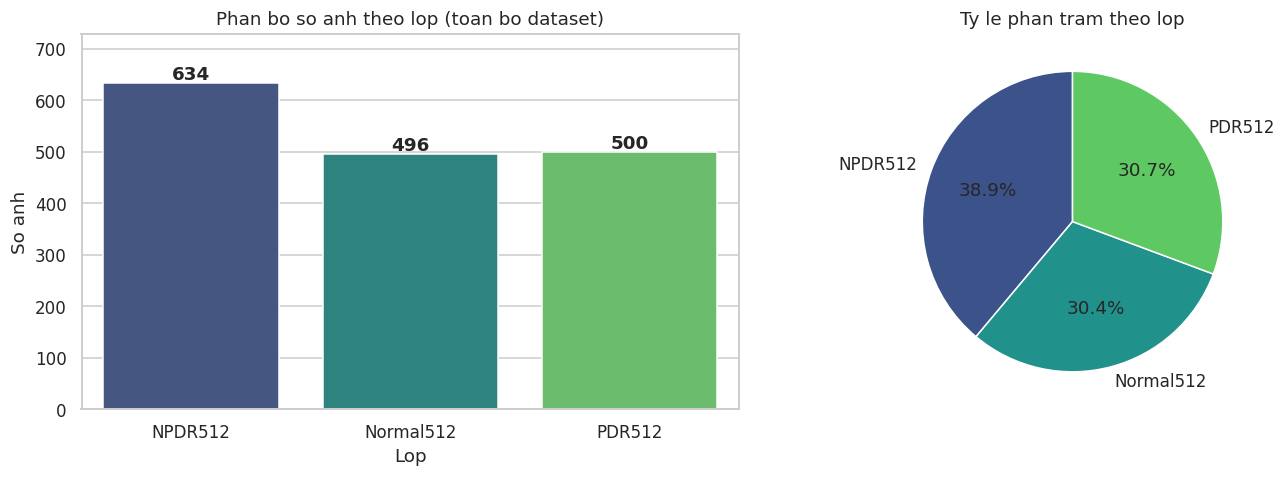

Lop nhieu nhat : NPDR512 (634 anh)
Lop it nhat    : Normal512 (496 anh)
Ty so mat can bang (max/min) = 1.28


In [14]:
# --- 3.1 Phan bo lop ---
cnt = df_all["class_name"].value_counts().reindex(CLASS_NAMES)
pct = (cnt / cnt.sum() * 100).round(2)
dist_df = pd.DataFrame({"so_anh": cnt, "ty_le_%": pct})
display(dist_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=cnt.index, y=cnt.values, ax=axes[0], hue=cnt.index, legend=False, palette="viridis")
for i, v in enumerate(cnt.values):
    axes[0].text(i, v + max(cnt.values) * 0.01, str(v), ha="center", fontweight="bold")
axes[0].set_title("Phan bo so anh theo lop (toan bo dataset)")
axes[0].set_xlabel("Lop")
axes[0].set_ylabel("So anh")
axes[0].set_ylim(0, max(cnt.values) * 1.15)

axes[1].pie(cnt.values, labels=cnt.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("viridis", len(cnt)))
axes[1].set_title("Ty le phan tram theo lop")
plt.tight_layout()
plt.show()

imbalance_ratio = float(cnt.max() / cnt.min())
print("Lop nhieu nhat : {} ({} anh)".format(cnt.idxmax(), int(cnt.max())))
print("Lop it nhat    : {} ({} anh)".format(cnt.idxmin(), int(cnt.min())))
print("Ty so mat can bang (max/min) = {:.2f}".format(imbalance_ratio))

In [15]:
# --- Tu dong sinh nhan xet ve mat can bang lop dua tren so lieu thuc te ---
if imbalance_ratio < 1.5:
    muc_do = "NHE - gan nhu can bang"
    khuyen_nghi = (
        "Co the dung accuracy lam thuoc do chinh, nhung van nen bao cao them macro-F1. "
        "Class weights chi giup rat it."
    )
elif imbalance_ratio < 3:
    muc_do = "TRUNG BINH"
    khuyen_nghi = (
        "Nen dung class weights trong CrossEntropyLoss va uu tien macro-F1 hon accuracy "
        "khi so sanh cac mo hinh."
    )
else:
    muc_do = "NANG"
    khuyen_nghi = (
        "Bat buoc xu ly mat can bang: class weights / focal loss / oversampling "
        "(WeightedRandomSampler), va danh gia bang macro-F1 + balanced accuracy."
    )

print("=" * 78)
print("NHAN XET VE PHAN BO LOP (sinh tu du lieu thuc te)")
print("=" * 78)
print("- Bo du lieu co {} lop: {}".format(NUM_CLASSES, ", ".join(CLASS_NAMES)))
print("- Tong cong {} anh; trung binh {:.1f} anh/lop.".format(len(df_all), len(df_all) / NUM_CLASSES))
print(
    "- Lop nhieu nhat '{}' co {} anh; lop it nhat '{}' co {} anh -> ty so {:.2f}.".format(
        cnt.idxmax(), int(cnt.max()), cnt.idxmin(), int(cnt.min()), imbalance_ratio
    )
)
print("- Muc do mat can bang: {}.".format(muc_do))
print("- Khuyen nghi: {}".format(khuyen_nghi))
print(
    "- Baseline 'doan luon lop da so' se dat accuracy = {:.2f}% -> moi mo hinh phai vuot xa nguong nay.".format(
        cnt.max() / cnt.sum() * 100
    )
)
print("=" * 78)

NHAN XET VE PHAN BO LOP (sinh tu du lieu thuc te)
- Bo du lieu co 3 lop: NPDR512, Normal512, PDR512
- Tong cong 1630 anh; trung binh 543.3 anh/lop.
- Lop nhieu nhat 'NPDR512' co 634 anh; lop it nhat 'Normal512' co 496 anh -> ty so 1.28.
- Muc do mat can bang: NHE - gan nhu can bang.
- Khuyen nghi: Co the dung accuracy lam thuoc do chinh, nhung van nen bao cao them macro-F1. Class weights chi giup rat it.
- Baseline 'doan luon lop da so' se dat accuracy = 38.90% -> moi mo hinh phai vuot xa nguong nay.


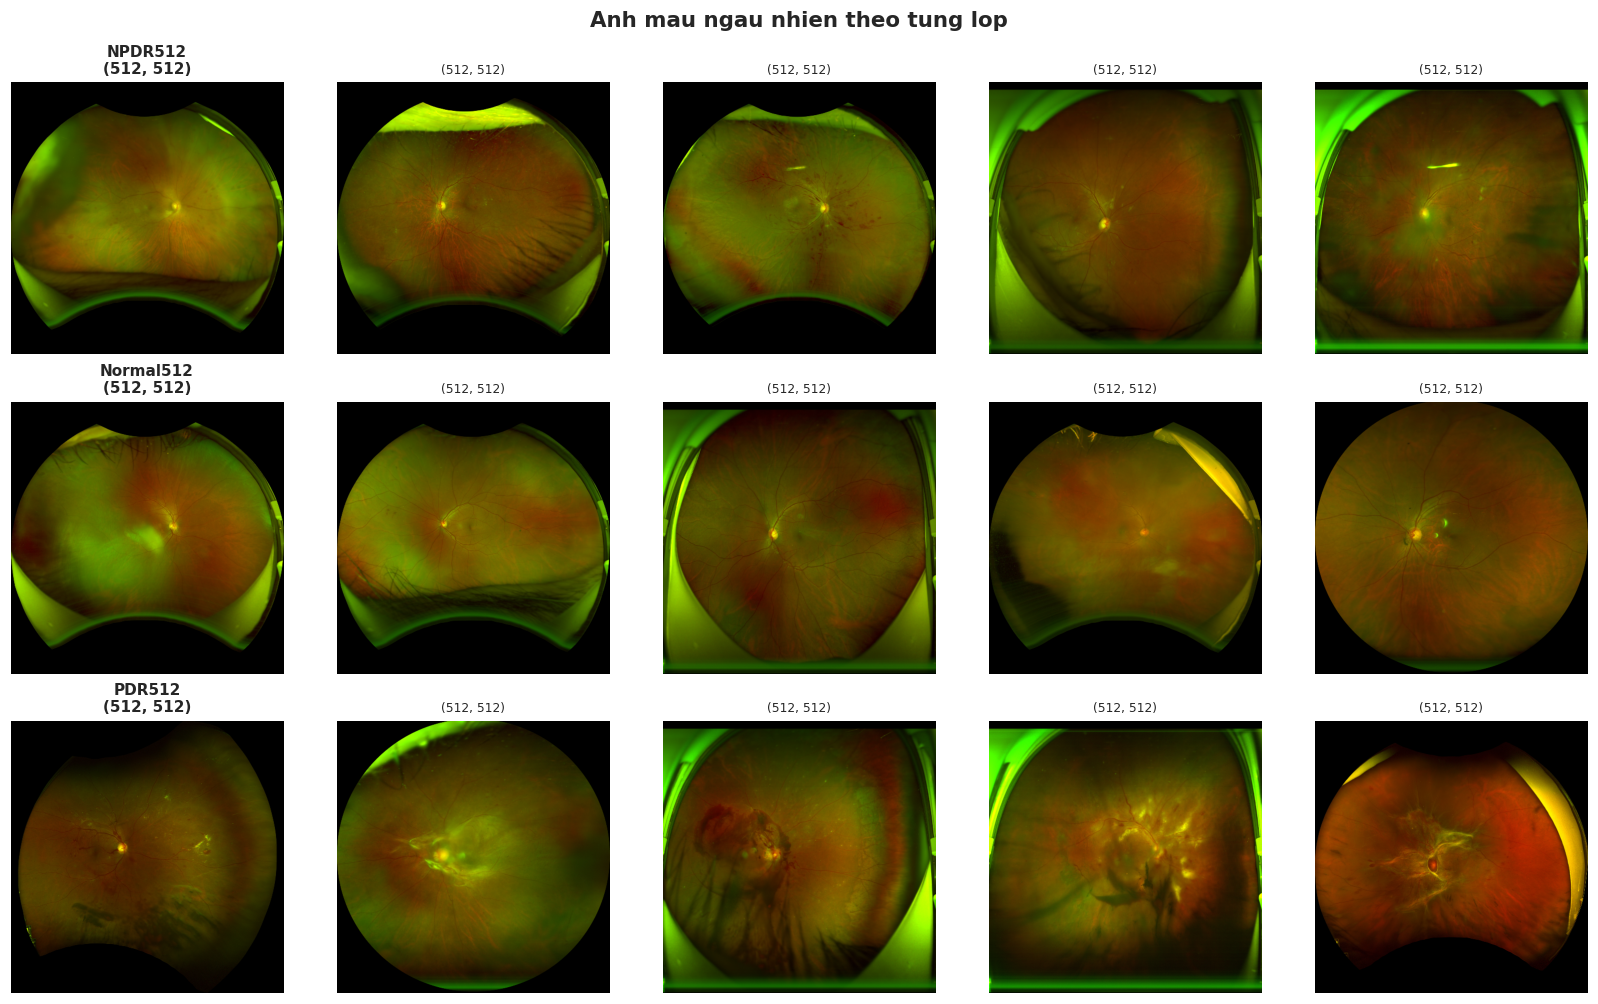

In [16]:
# --- 3.2 Luoi anh mau moi lop ---
N_SHOW = 5
fig, axes = plt.subplots(NUM_CLASSES, N_SHOW, figsize=(3.0 * N_SHOW, 3.1 * NUM_CLASSES))
axes = np.atleast_2d(axes)
rng = np.random.default_rng(SEED)

for r, cls in enumerate(CLASS_NAMES):
    paths = df_all.loc[df_all["class_name"] == cls, "filepath"].tolist()
    pick = rng.choice(len(paths), size=min(N_SHOW, len(paths)), replace=False)
    for c in range(N_SHOW):
        ax = axes[r, c]
        ax.axis("off")
        if c < len(pick):
            img = Image.open(paths[pick[c]]).convert("RGB")
            ax.imshow(img)
            if c == 0:
                ax.set_title("{}\n{}".format(cls, img.size), fontsize=10, fontweight="bold")
            else:
                ax.set_title(str(img.size), fontsize=8)

plt.suptitle("Anh mau ngau nhien theo tung lop", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Doc metadata anh:   0%|          | 0/400 [00:00<?, ?it/s]

Thong ke tren 400 anh lay mau:


,mean,std,min,50%,max
width,512.0,0.0,512.0,512.0,512.0
height,512.0,0.0,512.0,512.0,512.0
file_kb,239.3,32.9,183.8,229.3,331.2



Che do mau (PIL mode): {'RGB': 400}
Cac cap (W,H) pho bien nhat: [((512, 512), 400)]


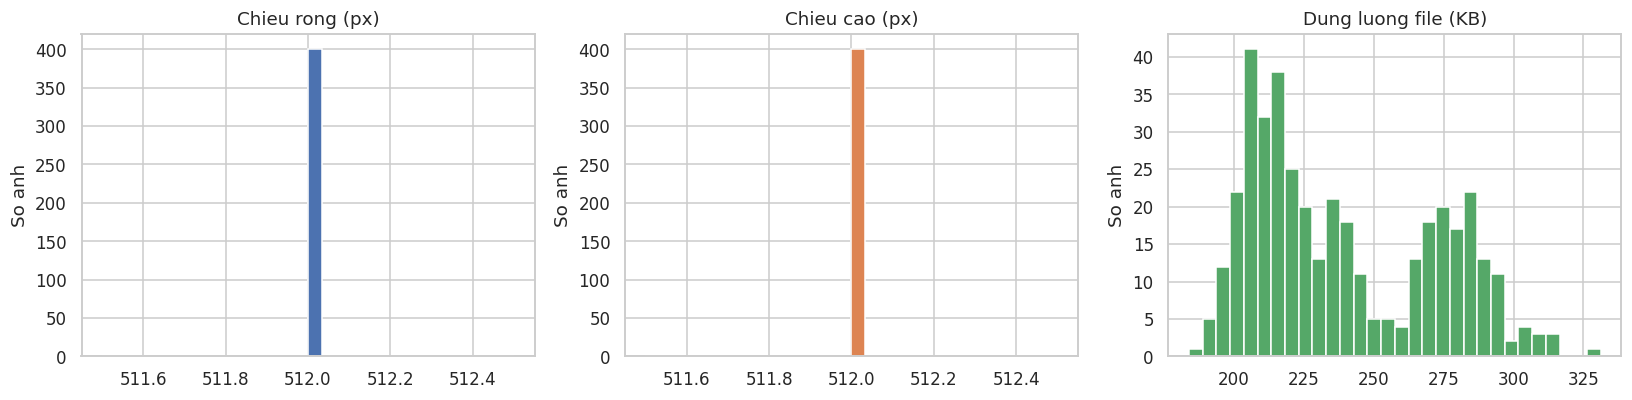


-> Co 1 kich thuoc khac nhau trong mau. Anh dong nhat kich thuoc nen resize rat an toan.


In [17]:
# --- 3.3 Thong ke kich thuoc & kenh mau anh ---
SAMPLE_FOR_STATS = min(400, len(df_all))
sample_paths = df_all["filepath"].sample(SAMPLE_FOR_STATS, random_state=SEED).tolist()

ws, hs, modes, sizes_kb = [], [], [], []
for p in tqdm(sample_paths, desc="Doc metadata anh"):
    try:
        with Image.open(p) as im:
            ws.append(im.size[0])
            hs.append(im.size[1])
            modes.append(im.mode)
        sizes_kb.append(os.path.getsize(p) / 1024)
    except Exception as exc:
        print("Loi doc", p, exc)

size_stats = pd.DataFrame({"width": ws, "height": hs, "file_kb": sizes_kb})
print("Thong ke tren {} anh lay mau:".format(len(size_stats)))
display(size_stats.describe().T[["mean", "std", "min", "50%", "max"]].round(1))
print("\nChe do mau (PIL mode):", dict(Counter(modes)))
print("Cac cap (W,H) pho bien nhat:", Counter(zip(ws, hs)).most_common(5))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].hist(ws, bins=30, color="#4C72B0")
ax[0].set_title("Chieu rong (px)")
ax[1].hist(hs, bins=30, color="#DD8452")
ax[1].set_title("Chieu cao (px)")
ax[2].hist(sizes_kb, bins=30, color="#55A868")
ax[2].set_title("Dung luong file (KB)")
for a in ax:
    a.set_ylabel("So anh")
plt.tight_layout()
plt.show()

uniq_sizes = len(set(zip(ws, hs)))
print(
    "\n-> Co {} kich thuoc khac nhau trong mau. {}".format(
        uniq_sizes,
        "Anh dong nhat kich thuoc nen resize rat an toan."
        if uniq_sizes <= 3
        else "Anh khong dong nhat -> bat buoc resize ve cung kich thuoc {}x{}.".format(IMG_SIZE, IMG_SIZE),
    )
)

### Nhận xét EDA

*Các nhận xét dưới đây dựa trên số liệu thực tế được in ra ở các cell ngay phía trên.*

* **Về phân bố lớp:** hãy đọc dòng `Ty so mat can bang (max/min)`. Với bộ UWF-DR gốc,
  tỉ số này là `634 / 496 ≈ 1.28`, tức mất cân bằng **rất nhẹ**. Điều đó có nghĩa accuracy
  vẫn là thước đo tương đối đáng tin, nhưng ta vẫn sẽ báo cáo thêm **macro-F1** vì macro-F1
  đối xử công bằng giữa các lớp và sẽ phơi bày ngay nếu một lớp bị mô hình "bỏ rơi".
* **Về ảnh:** ảnh UWF SLO là ảnh đáy mắt góc siêu rộng (~200°), có vùng viền tối lớn và
  màu giả (pseudo-color, thiên xanh lá / đỏ). Vùng thông tin hữu ích nằm ở trung tâm.
  Vì ảnh đã đồng nhất 512×512, việc `Resize` về 224×224 là an toàn và không làm méo tỉ lệ.
* **Về độ khó bài toán:** phân biệt `Normal` với `PDR` thường dễ (PDR có tân mạch, xuất huyết
  dịch kính, sẹo laser rất rõ). Cặp khó nhất dự kiến là **`NPDR` ↔ `PDR`** và **`Normal` ↔ `NPDR` nhẹ**,
  vì tổn thương NPDR sớm (vi phình mạch, xuất tiết nhỏ) chỉ chiếm vài chục pixel trên ảnh 224×224 —
  đây là lý do chính khiến việc giảm độ phân giải làm mất thông tin. Phần confusion matrix ở mục 8
  sẽ kiểm chứng dự đoán này bằng số liệu thật.

---
## 4. Chia tập dữ liệu theo tỉ lệ 7 : 1 : 2

Yêu cầu đề bài: **train : validation : test = 7 : 1 : 2**.

Cách làm: dùng `train_test_split` **hai lần**, đều có `stratify=` để giữ nguyên tỉ lệ các lớp
trong từng tập, và `random_state=SEED` để tái lập được.

```
Toàn bộ (100%)
   ├── split 1: test_size = 0.20  → TEST  (20%)
   └── phần còn lại (80%)
          └── split 2: test_size = 0.125 → VAL (0.80 × 0.125 = 10%)
                                          → TRAIN (0.80 × 0.875 = 70%)
```

Lưu ý về **data leakage**: bộ dữ liệu gốc có 1.630 ảnh từ 809 bệnh nhân, tức trung bình ~2 ảnh
(2 mắt) mỗi bệnh nhân. Cách chia chuẩn về mặt y khoa là chia **theo bệnh nhân** (patient-level split)
để hai mắt của cùng một người không rơi vào hai tập khác nhau. Tuy nhiên file ảnh trong bản phát hành
không kèm mã bệnh nhân có thể suy ra chắc chắn, nên ở đây ta chia **theo ảnh (image-level)** đúng như
tác giả đã làm trong bài báo. Đây là một hạn chế được ghi nhận rõ và sẽ nhắc lại ở phần kết luận.

In [18]:
# --- Chia 7:1:2 co phan tang, co seed ---
TEST_RATIO = 0.20
VAL_RATIO = 0.10
TRAIN_RATIO = 0.70
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

# Buoc 1: tach TEST = 20%
df_trainval, df_test = train_test_split(
    df_used,
    test_size=TEST_RATIO,
    stratify=df_used["label"],
    random_state=SEED,
    shuffle=True,
)

# Buoc 2: tach VAL tu phan con lai. 0.10 / 0.80 = 0.125
val_size_rel = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_size_rel,
    stratify=df_trainval["label"],
    random_state=SEED,
    shuffle=True,
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

n_total = len(df_used)
print("Tong so anh su dung :", n_total)
print("TRAIN : {:5d} anh  ({:.2f}%)".format(len(df_train), 100 * len(df_train) / n_total))
print("VAL   : {:5d} anh  ({:.2f}%)".format(len(df_val), 100 * len(df_val) / n_total))
print("TEST  : {:5d} anh  ({:.2f}%)".format(len(df_test), 100 * len(df_test) / n_total))

Tong so anh su dung : 180
TRAIN :   125 anh  (69.44%)
VAL   :    19 anh  (10.56%)
TEST  :    36 anh  (20.00%)


In [19]:
# --- Kiem chung ty le va tinh toan ven cua phep chia ---
r_tr = len(df_train) / n_total
r_va = len(df_val) / n_total
r_te = len(df_test) / n_total

TOL = 0.015  # sai so cho phep do lam tron khi so anh nho
assert abs(r_tr - 0.70) < TOL, "Ty le train lech: {:.4f}".format(r_tr)
assert abs(r_va - 0.10) < TOL, "Ty le val lech: {:.4f}".format(r_va)
assert abs(r_te - 0.20) < TOL, "Ty le test lech: {:.4f}".format(r_te)
assert len(df_train) + len(df_val) + len(df_test) == n_total, "Mat/thua anh sau khi chia!"

# Khong duoc trung file giua cac tap
s_tr, s_va, s_te = set(df_train.filepath), set(df_val.filepath), set(df_test.filepath)
assert not (s_tr & s_va) and not (s_tr & s_te) and not (s_va & s_te), "Co anh bi trung giua cac tap!"

print("[OK] Ty le 7:1:2 dat yeu cau (sai so < {:.1%}).".format(TOL))
print("[OK] Khong co anh nao xuat hien o hai tap khac nhau (khong ro ri du lieu o muc anh).")

[OK] Ty le 7:1:2 dat yeu cau (sai so < 1.5%).
[OK] Khong co anh nao xuat hien o hai tap khac nhau (khong ro ri du lieu o muc anh).


So anh theo lop x tap:


,train,val,test,TONG
class_name,,,,
NPDR512,42,6,12,60
Normal512,42,6,12,60
PDR512,41,7,12,60
TONG,125,19,36,180



Phan bo % cac lop BEN TRONG tung tap (kiem tra stratify hoat dong dung):


,train,val,test
class_name,,,
NPDR512,33.6,31.58,33.33
Normal512,33.6,31.58,33.33
PDR512,32.8,36.84,33.33


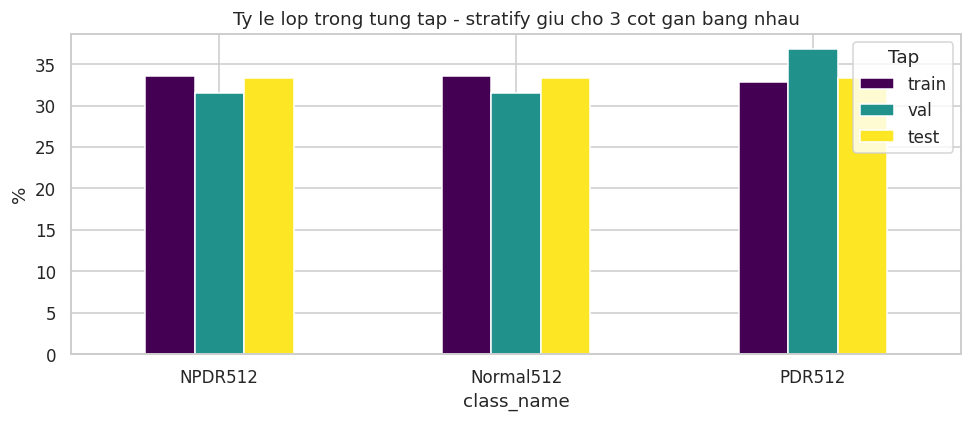

Do lech ty le lop lon nhat giua cac tap: 4.04 diem phan tram
-> Stratify hoat dong tot, phan bo lop gan nhu dong nhat giua 3 tap.


In [20]:
# --- Bang so luong theo lop x theo tap ---
split_tbl = pd.DataFrame(
    {
        "train": df_train["class_name"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int),
        "val": df_val["class_name"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int),
        "test": df_test["class_name"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int),
    }
)
split_tbl["TONG"] = split_tbl.sum(axis=1)
split_tbl.loc["TONG"] = split_tbl.sum(axis=0)
print("So anh theo lop x tap:")
display(split_tbl)

pct_tbl = pd.DataFrame(
    {
        c: (split_tbl.loc[CLASS_NAMES, c] / split_tbl.loc[CLASS_NAMES, c].sum() * 100).round(2)
        for c in ["train", "val", "test"]
    }
)
print("\nPhan bo % cac lop BEN TRONG tung tap (kiem tra stratify hoat dong dung):")
display(pct_tbl)

ax = pct_tbl.plot(kind="bar", figsize=(9, 4), rot=0, colormap="viridis")
ax.set_title("Ty le lop trong tung tap - stratify giu cho 3 cot gan bang nhau")
ax.set_ylabel("%")
ax.legend(title="Tap")
plt.tight_layout()
plt.show()

max_dev = float((pct_tbl.max(axis=1) - pct_tbl.min(axis=1)).max())
print("Do lech ty le lop lon nhat giua cac tap: {:.2f} diem phan tram".format(max_dev))
print(
    "-> {}".format(
        "Stratify hoat dong tot, phan bo lop gan nhu dong nhat giua 3 tap."
        if max_dev < 5
        else "Do lech hoi lon (do so anh nho); voi du lieu day du se giam xuong."
    )
)

---
## 5. Pipeline dữ liệu & tăng cường ảnh (augmentation)

**Tập train** dùng augmentation để chống overfitting và mô phỏng biến thiên thật khi chụp ảnh:

| Phép biến đổi | Lý do dùng cho ảnh đáy mắt |
|---|---|
| `RandomResizedCrop(scale=(0.8,1.0))` | mô phỏng khác biệt vùng chụp / căn giữa của kỹ thuật viên |
| `RandomHorizontalFlip` | ảnh mắt trái ↔ mắt phải gần như đối xứng gương → hợp lệ về mặt y khoa |
| `RandomRotation(±15°)` | bệnh nhân nghiêng đầu khi chụp |
| `ColorJitter(brightness/contrast/saturation)` | khác biệt về đèn, thiết bị, sắc tố đáy mắt giữa các bệnh nhân |
| `RandomErasing` (nhẹ) | ép mô hình không phụ thuộc vào một vùng nhỏ duy nhất |

**Không dùng `RandomVerticalFlip`** vì lật dọc tạo ra giải phẫu đáy mắt không tồn tại trong thực tế
(đĩa thị và cung mạch máu có hướng cố định).

**Tập val/test** chỉ `Resize` + `CenterCrop` + chuẩn hoá — tuyệt đối không augment,
để phép đo là khách quan và tái lập.

**Chuẩn hoá:** dùng mean/std của ImageNet vì 4/5 mô hình khởi tạo từ trọng số ImageNet;
giữ đúng thống kê mà backbone đã quen sẽ giúp hội tụ nhanh hơn.

**Về `DataLoader` trên Colab:** Colab chạy Linux nên dùng được đa tiến trình —
đặt `num_workers=2` (Colab thường chỉ cấp 2 vCPU), `pin_memory=True` để copy sang GPU nhanh hơn,
và `persistent_workers=True` để không phải khởi tạo lại worker sau mỗi epoch.

In [21]:
# --- Transform ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose(
    [
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.10)),
    ]
)

eval_tf = transforms.Compose(
    [
        transforms.Resize(int(IMG_SIZE * 1.14)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

# Transform chi de HIEN THI (khong chuan hoa) - dung cho luoi anh minh hoa
show_tf = transforms.Compose(
    [transforms.Resize(int(IMG_SIZE * 1.14)), transforms.CenterCrop(IMG_SIZE)]
)
print("Da dinh nghia train_tf / eval_tf voi IMG_SIZE =", IMG_SIZE)

Da dinh nghia train_tf / eval_tf voi IMG_SIZE = 224


In [22]:
# --- Dataset doc tu danh sach file da chia ---
class EyeDiseaseDataset(Dataset):
    # Dataset kieu ImageFolder nhung nhan dau vao la DataFrame (filepath, label)
    def __init__(self, df, transform=None, class_names=None):
        self.paths = df["filepath"].tolist()
        self.labels = df["label"].tolist()
        self.transform = transform
        self.class_names = class_names or CLASS_NAMES

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]

    def raw_image(self, idx):
        # Tra ve anh PIL da resize (chua chuan hoa) de ve minh hoa
        return show_tf(Image.open(self.paths[idx]).convert("RGB"))


train_ds = EyeDiseaseDataset(df_train, train_tf)
val_ds = EyeDiseaseDataset(df_val, eval_tf)
test_ds = EyeDiseaseDataset(df_test, eval_tf)

g = torch.Generator()
g.manual_seed(SEED)

loader_kw = dict(
    num_workers=NUM_WORKERS,
    pin_memory=CUDA_OK,
    persistent_workers=(NUM_WORKERS > 0),
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, generator=g, **loader_kw
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kw)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kw)

print("train_ds:", len(train_ds), "| val_ds:", len(val_ds), "| test_ds:", len(test_ds))
print("So batch : train={} val={} test={}".format(len(train_loader), len(val_loader), len(test_loader)))
print("DataLoader:", loader_kw)

train_ds: 125 | val_ds: 19 | test_ds: 36
So batch : train=3 val=1 test=1
DataLoader: {'num_workers': 2, 'pin_memory': True, 'persistent_workers': True}


Kich thuoc batch anh : (48, 3, 224, 224) | dtype: torch.float32
Kich thuoc batch nhan: (48,) | gia tri: [0, 1, 2]
Gia tri tensor sau chuan hoa: min=-2.118 max=2.429 mean=-1.275


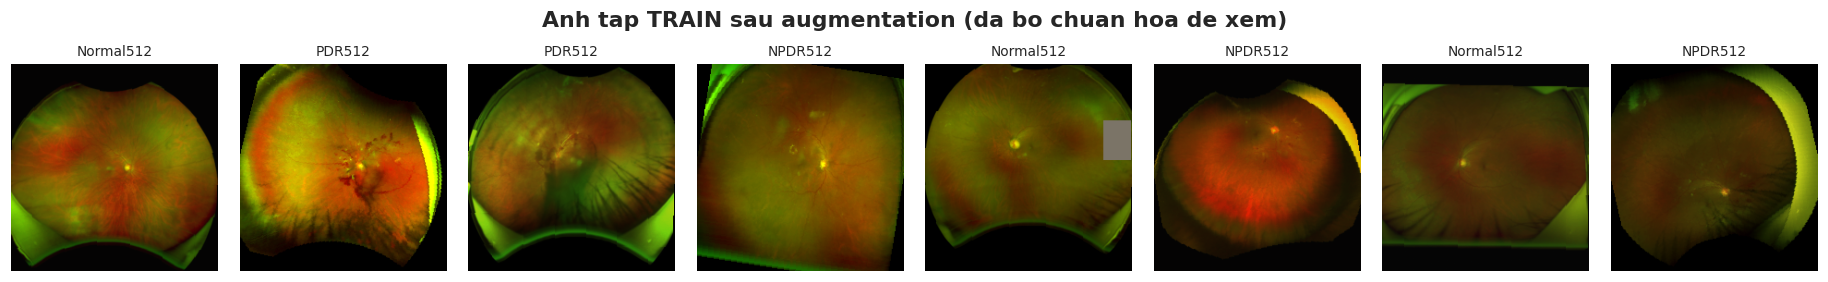

In [23]:
# --- Kiem tra nhanh mot batch + xem anh sau augmentation ---
xb, yb = next(iter(train_loader))
print("Kich thuoc batch anh :", tuple(xb.shape), "| dtype:", xb.dtype)
print("Kich thuoc batch nhan:", tuple(yb.shape), "| gia tri:", sorted(set(yb.tolist())))
print("Gia tri tensor sau chuan hoa: min={:.3f} max={:.3f} mean={:.3f}".format(
    xb.min().item(), xb.max().item(), xb.mean().item()))


def denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    s = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.cpu() * s + m).clamp(0, 1).permute(1, 2, 0).numpy()


n_show = min(8, xb.size(0))
fig, axes = plt.subplots(1, n_show, figsize=(2.1 * n_show, 2.6))
for i in range(n_show):
    axes[i].imshow(denorm(xb[i]))
    axes[i].set_title(CLASS_NAMES[yb[i].item()], fontsize=9)
    axes[i].axis("off")
plt.suptitle("Anh tap TRAIN sau augmentation (da bo chuan hoa de xem)", fontweight="bold")
plt.tight_layout()
plt.show()

In [24]:
# --- Trong so lop de bu mat can bang trong CrossEntropyLoss ---
train_labels = df_train["label"].to_numpy()
cls_w = compute_class_weight(class_weight="balanced", classes=np.arange(NUM_CLASSES), y=train_labels)
class_weights = torch.tensor(cls_w, dtype=torch.float32, device=DEVICE)

display(
    pd.DataFrame(
        {
            "lop": CLASS_NAMES,
            "so_anh_train": [int((train_labels == i).sum()) for i in range(NUM_CLASSES)],
            "trong_so": np.round(cls_w, 4),
        }
    )
)
print("USE_CLASS_WEIGHTS =", USE_CLASS_WEIGHTS)
print("-> Trong so cang lon nghia la lop do cang it anh va se duoc phat nang hon khi du doan sai.")

,lop,so_anh_train,trong_so
0,NPDR512,42,0.9921
1,Normal512,42,0.9921
2,PDR512,41,1.0163


USE_CLASS_WEIGHTS = True
-> Trong so cang lon nghia la lop do cang it anh va se duoc phat nang hon khi du doan sai.


---
## 6. Xây dựng các mô hình CNN

Notebook huấn luyện **5 kiến trúc**, cố tình trộn 1 mô hình *from scratch* và 4 mô hình
*transfer learning* để so sánh được vai trò của việc tiền huấn luyện:

| # | Tên | Kiểu | Ý tưởng kiến trúc | Tham số (xấp xỉ) |
|---|---|---|---|---|
| a | `simple_cnn` | **Scratch** | 4 khối `Conv-BN-ReLU-Conv-BN-ReLU-MaxPool`, GAP + Dropout + FC | ~1.3 M |
| b | `resnet18` | Transfer | Residual connection, giải quyết vanishing gradient, khá nông | ~11 M |
| c | `efficientnet_b0` | Transfer | Compound scaling + MBConv + Squeeze-Excitation | ~4 M |
| d | `densenet121` | Transfer | Dense connectivity, tái sử dụng đặc trưng rất mạnh | ~7 M |
| e | `mobilenet_v3_large` | Transfer | Depthwise-separable conv, thiết kế cho thiết bị yếu | ~4.2 M |

Tất cả được tạo qua **một factory duy nhất** `build_model(name)` để vòng lặp huấn luyện dùng chung
được cho mọi kiến trúc. (Factory còn hỗ trợ `resnet50` và `vgg16` nếu muốn thử thêm — chỉ cần
thêm tên vào `MODELS_TO_TRAIN`.)

**Chiến lược fine-tune:** mở khoá **toàn bộ** backbone (full fine-tuning) thay vì đóng băng, vì
ảnh đáy mắt UWF khác miền ảnh ImageNet rất xa — các đặc trưng tầng cao của ImageNet
(mặt mèo, bánh xe…) gần như vô dụng, chỉ có đặc trưng tầng thấp (cạnh, texture, màu) là dùng lại được.
Learning rate nhỏ (`3e-4` với AdamW) giúp không phá hỏng trọng số tiền huấn luyện.

> **Lưu ý:** lần chạy đầu, torchvision sẽ tải trọng số ImageNet về `~/.cache/torch/hub/checkpoints`
> (vài chục MB mỗi mô hình, rất nhanh trên Colab). Nếu vì lý do nào đó không tải được, code
> **tự động chuyển sang khởi tạo ngẫu nhiên** và in cảnh báo — khi đó phần "transfer learning"
> mất ý nghĩa và kết quả sẽ thấp hơn đáng kể.

In [25]:
# --- (a) CNN tu xay tu dau ---
class SimpleCNN(nn.Module):
    # 4 khoi conv, moi khoi: [Conv-BN-ReLU] x2 -> MaxPool. Ket thuc bang GAP + Dropout + FC.
    def __init__(self, num_classes, in_ch=3, widths=(32, 64, 128, 256), p_drop=0.4):
        super().__init__()
        blocks = []
        c_prev = in_ch
        for c in widths:
            blocks.append(self._block(c_prev, c))
            c_prev = c
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p_drop),
            nn.Linear(c_prev, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop / 2),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    @staticmethod
    def _block(cin, cout):
        return nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


_m = SimpleCNN(NUM_CLASSES)
_out = _m(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE))
print("SimpleCNN OK - output shape:", tuple(_out.shape))
del _m, _out

SimpleCNN OK - output shape: (2, 3)


In [26]:
# --- Factory tao mo hinh ---
PRETRAINED_AVAILABLE = {}   # ghi nhan mo hinh nao that su tai duoc weights ImageNet


def _get_weights(weight_enum):
    # Tra ve weights ImageNet neu tai duoc, nguoc lai None (khoi tao ngau nhien)
    try:
        return weight_enum.DEFAULT
    except Exception as exc:
        print("   [!] Khong lay duoc weights:", repr(exc))
        return None


def _safe_build(fn, weight_enum, name):
    try:
        w = _get_weights(weight_enum)
        m = fn(weights=w)
        PRETRAINED_AVAILABLE[name] = w is not None
        return m
    except Exception as exc:
        print("   [!] Tai weights pretrained that bai cho {} ({}). "
              "Chuyen sang khoi tao NGAU NHIEN.".format(name, type(exc).__name__))
        PRETRAINED_AVAILABLE[name] = False
        return fn(weights=None)


def build_model(name, num_classes=NUM_CLASSES, pretrained=True):
    name = name.lower()

    if name == "simple_cnn":
        PRETRAINED_AVAILABLE[name] = False
        return SimpleCNN(num_classes)

    if name in ("resnet18", "resnet50"):
        enum = tv_models.ResNet18_Weights if name == "resnet18" else tv_models.ResNet50_Weights
        fn = tv_models.resnet18 if name == "resnet18" else tv_models.resnet50
        m = _safe_build(fn, enum, name) if pretrained else fn(weights=None)
        m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, num_classes))
        return m

    if name == "efficientnet_b0":
        m = _safe_build(tv_models.efficientnet_b0, tv_models.EfficientNet_B0_Weights, name) \
            if pretrained else tv_models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        return m

    if name == "densenet121":
        m = _safe_build(tv_models.densenet121, tv_models.DenseNet121_Weights, name) \
            if pretrained else tv_models.densenet121(weights=None)
        m.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.classifier.in_features, num_classes))
        return m

    if name == "mobilenet_v3_large":
        m = _safe_build(tv_models.mobilenet_v3_large, tv_models.MobileNet_V3_Large_Weights, name) \
            if pretrained else tv_models.mobilenet_v3_large(weights=None)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
        return m

    if name == "vgg16":
        # Nang & cham hon nhieu - chi bat neu con nhieu thoi gian GPU
        m = _safe_build(tv_models.vgg16_bn, tv_models.VGG16_BN_Weights, name) \
            if pretrained else tv_models.vgg16_bn(weights=None)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
        return m

    raise ValueError("Khong ho tro mo hinh: {}".format(name))


MODEL_KIND = {
    "simple_cnn": "Scratch (tu xay)",
    "resnet18": "Transfer (ImageNet)",
    "resnet50": "Transfer (ImageNet)",
    "efficientnet_b0": "Transfer (ImageNet)",
    "densenet121": "Transfer (ImageNet)",
    "mobilenet_v3_large": "Transfer (ImageNet)",
    "vgg16": "Transfer (ImageNet)",
}
print("Factory san sang. Cac mo hinh ho tro:", list(MODEL_KIND))

Factory san sang. Cac mo hinh ho tro: ['simple_cnn', 'resnet18', 'resnet50', 'efficientnet_b0', 'densenet121', 'mobilenet_v3_large', 'vgg16']


In [27]:
# --- Dem tham so tung mo hinh (dong thoi tai truoc weights ImageNet ve cache) ---
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


rows = []
for nm in MODELS_TO_TRAIN:
    print("Dang khoi tao:", nm)
    mdl = build_model(nm)
    tot, tra = count_params(mdl)
    rows.append(
        {
            "model": nm,
            "kieu": MODEL_KIND.get(nm, "?"),
            "pretrained_tai_duoc": PRETRAINED_AVAILABLE.get(nm, False),
            "tong_tham_so_M": round(tot / 1e6, 2),
            "tham_so_huan_luyen_M": round(tra / 1e6, 2),
        }
    )
    del mdl

param_df = pd.DataFrame(rows)
display(param_df)

if not param_df.loc[param_df["kieu"].str.startswith("Transfer"), "pretrained_tai_duoc"].all():
    print(
        "\n[!] CANH BAO: mot so mo hinh KHONG tai duoc trong so ImageNet.\n"
        "    Chung se duoc huan luyen tu dau -> ket qua se thap hon dang ke va phan so sanh\n"
        "    'scratch vs transfer learning' se khong con y nghia. Hay chay lai cell nay."
    )
else:
    print("\n[OK] Tat ca mo hinh transfer deu tai duoc trong so ImageNet.")

Dang khoi tao: simple_cnn
Dang khoi tao: resnet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s] 


Dang khoi tao: efficientnet_b0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 203MB/s]


Dang khoi tao: densenet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 216MB/s]


Dang khoi tao: mobilenet_v3_large
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:01<00:00, 18.9MB/s]


,model,kieu,pretrained_tai_duoc,tong_tham_so_M,tham_so_huan_luyen_M
0,simple_cnn,Scratch (tu xay),False,1.24,1.24
1,resnet18,Transfer (ImageNet),True,11.18,11.18
2,efficientnet_b0,Transfer (ImageNet),True,4.01,4.01
3,densenet121,Transfer (ImageNet),True,6.96,6.96
4,mobilenet_v3_large,Transfer (ImageNet),True,4.21,4.21



[OK] Tat ca mo hinh transfer deu tai duoc trong so ImageNet.


---
## 7. Hàm huấn luyện dùng chung

`train_model(...)` gói toàn bộ vòng lặp huấn luyện, dùng chung cho mọi kiến trúc:

* **Loss:** `CrossEntropyLoss` có `weight=class_weights` (bù mất cân bằng) + `label_smoothing=0.05`
  (giúp mô hình bớt "quá tự tin", cải thiện hiệu chuẩn xác suất).
* **Optimizer:** `AdamW` (Adam + weight decay tách rời) — ổn định, ít phải chỉnh tay.
* **Scheduler:** `ReduceLROnPlateau` trên `val_loss` — khi val_loss chững lại thì giảm LR ×0.5.
* **Early stopping:** dừng sau `patience` epoch không cải thiện `val_loss` → tiết kiệm thời gian
  GPU của Colab và chống overfitting.
* **Best checkpoint:** mỗi lần `val_loss` cải thiện là **ghi ngay checkpoint xuống `CKPT_DIR`**
  (Google Drive nếu đã mount). Nhờ vậy nếu phiên Colab bị ngắt giữa chừng thì vẫn còn trọng số tốt nhất
  tính tới thời điểm đó, kèm file `<model>_history.csv` để vẽ lại learning curve.
* **History:** ghi `train_loss`, `train_acc`, `val_loss`, `val_acc`, `lr` từng epoch.
* **AMP (mixed precision):** bật tự động khi có CUDA → nhanh hơn ~1.5–2× và tốn ít VRAM hơn.

In [28]:
# --- Cac ham tien ich huan luyen / danh gia ---
@torch.no_grad()
def evaluate(model, loader, criterion, device=DEVICE, return_outputs=False):
    model.eval()
    tot_loss, n = 0.0, 0
    all_logits, all_targets = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        tot_loss += loss.item() * xb.size(0)
        n += xb.size(0)
        all_logits.append(logits.detach().float().cpu())
        all_targets.append(yb.detach().cpu())
    logits = torch.cat(all_logits)
    targets = torch.cat(all_targets)
    preds = logits.argmax(1)
    acc = (preds == targets).float().mean().item()
    avg_loss = tot_loss / max(n, 1)
    if return_outputs:
        probs = torch.softmax(logits, dim=1).numpy()
        return avg_loss, acc, targets.numpy(), preds.numpy(), probs
    return avg_loss, acc


def train_one_epoch(model, loader, criterion, optimizer, scaler, device=DEVICE, desc=""):
    model.train()
    tot_loss, correct, n = 0.0, 0, 0
    bar = tqdm(loader, desc=desc, leave=False)
    for xb, yb in bar:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        bs = xb.size(0)
        tot_loss += loss.item() * bs
        correct += (logits.detach().argmax(1) == yb).sum().item()
        n += bs
        bar.set_postfix(loss="{:.4f}".format(tot_loss / n), acc="{:.4f}".format(correct / n))
    return tot_loss / max(n, 1), correct / max(n, 1)

In [29]:
def train_model(
    model_name,
    train_loader=None,
    val_loader=None,
    epochs=None,
    lr=None,
    weight_decay=None,
    patience=None,
    use_class_weights=None,
    device=DEVICE,
    seed=SEED,
    verbose=True,
):
    # Huan luyen mot mo hinh; tra ve (model da nap best weights, history dict, thong tin phu)
    train_loader = train_loader if train_loader is not None else globals()["train_loader"]
    val_loader = val_loader if val_loader is not None else globals()["val_loader"]
    epochs = epochs if epochs is not None else CFG["epochs"]
    lr = lr if lr is not None else CFG["lr"]
    weight_decay = weight_decay if weight_decay is not None else CFG["weight_decay"]
    patience = patience if patience is not None else CFG["patience"]
    use_class_weights = (
        use_class_weights if use_class_weights is not None else CFG["use_class_weights"]
    )

    set_seed(seed)  # moi mo hinh xuat phat tu cung mot trang thai ngau nhien
    model = build_model(model_name).to(device)

    w = class_weights if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=w, label_smoothing=CFG["label_smoothing"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=max(1, patience // 2), min_lr=1e-6
    )
    use_amp = CFG["use_amp"] and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda") if use_amp else None

    ckpt_path = CKPT_DIR / "{}_best.pt".format(model_name)
    hist_path = CKPT_DIR / "{}_history.csv".format(model_name)
    history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_epoch = -1
    bad_epochs = 0
    t0 = time.time()

    if verbose:
        print("=" * 88)
        print("HUAN LUYEN: {}  ({})".format(model_name, MODEL_KIND.get(model_name, "?")))
        print("device={} | epochs={} | lr={} | batch={} | amp={} | class_weights={}".format(
            device, epochs, lr, BATCH_SIZE, use_amp, use_class_weights))
        print("checkpoint ->", ckpt_path)
        print("=" * 88)

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device,
            desc="{} | ep {}/{}".format(model_name, ep, epochs),
        )
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        cur_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(va_loss)

        history["epoch"].append(ep)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(cur_lr)

        improved = va_loss < best_val_loss - 1e-5
        if improved:
            best_val_loss, best_val_acc, best_epoch = va_loss, va_acc, ep
            bad_epochs = 0
            # Luu NGAY khi cai thien -> mat ket noi Colab cung khong mat cong huan luyen
            torch.save(
                {
                    "model_name": model_name,
                    "epoch": ep,
                    "state_dict": model.state_dict(),
                    "val_loss": va_loss,
                    "val_acc": va_acc,
                    "class_names": CLASS_NAMES,
                    "img_size": IMG_SIZE,
                },
                ckpt_path,
            )
        else:
            bad_epochs += 1

        # Ghi history sau MOI epoch (de con doc lai neu phien bi ngat)
        pd.DataFrame(history).to_csv(hist_path, index=False)

        if verbose:
            print(
                "ep {:>2}/{:<2} | train loss {:.4f} acc {:.4f} | val loss {:.4f} acc {:.4f} "
                "| lr {:.2e} {}".format(
                    ep, epochs, tr_loss, tr_acc, va_loss, va_acc, cur_lr,
                    "  <-- best (da luu)" if improved
                    else "  (khong cai thien {}/{})".format(bad_epochs, patience),
                )
            )

        if bad_epochs >= patience:
            if verbose:
                print("--> Early stopping tai epoch {} (khong cai thien {} epoch lien tiep).".format(
                    ep, patience))
            break

    elapsed = time.time() - t0
    if ckpt_path.exists():
        ck = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ck["state_dict"])
    model.to(device).eval()
    if device.type == "cuda":
        torch.cuda.empty_cache()

    info = {
        "model_name": model_name,
        "kieu": MODEL_KIND.get(model_name, "?"),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "epochs_ran": len(history["epoch"]),
        "train_time_sec": elapsed,
        "ckpt": str(ckpt_path),
        "params_M": round(sum(p.numel() for p in model.parameters()) / 1e6, 2),
    }
    if verbose:
        print(
            "KET THUC {}: best epoch {} | val_loss {:.4f} | val_acc {:.4f} | {:.1f}s ({:.1f} phut)\n".format(
                model_name, best_epoch, best_val_loss, best_val_acc, elapsed, elapsed / 60
            )
        )
    return model, history, info

### 7.1. Chạy huấn luyện cho toàn bộ mô hình

Cell dưới lặp qua `MODELS_TO_TRAIN`. Mô hình đã huấn luyện được giữ trong `trained_models`,
lịch sử trong `histories`, thông tin tóm tắt trong `train_infos`.

Mẹo cho Colab:
* Nếu bị **CUDA out of memory**: giảm `CFG["batch_size"]` xuống 32/16 rồi chạy lại **chỉ cell này**.
* Nếu sợ hết thời gian GPU: rút gọn `MODELS_TO_TRAIN` còn 2–3 mô hình, hoặc giảm `CFG["epochs"]`.
* Đừng để tab Colab nhàn rỗi quá lâu — phiên có thể bị ngắt. Checkpoint đã được ghi vào Drive
  sau mỗi lần cải thiện nên vẫn giữ được kết quả tốt nhất.

In [30]:
# --- Vong lap huan luyen ---
trained_models, histories, train_infos = {}, {}, []

for nm in MODELS_TO_TRAIN:
    try:
        mdl, hist, info = train_model(nm)
        trained_models[nm] = mdl
        histories[nm] = hist
        train_infos.append(info)
    except RuntimeError as exc:
        msg = str(exc)
        print("[LOI] {} that bai: {}".format(nm, msg[:300]))
        if "out of memory" in msg.lower():
            print('     -> Giam CFG["batch_size"] (vd 32 hoac 16) roi chay lai cell nay.')
        if CUDA_OK:
            torch.cuda.empty_cache()

train_info_df = pd.DataFrame(train_infos)
if len(train_info_df):
    train_info_df["train_time_min"] = (train_info_df["train_time_sec"] / 60).round(2)
    display(
        train_info_df[
            ["model_name", "kieu", "params_M", "best_epoch", "epochs_ran",
             "best_val_loss", "best_val_acc", "train_time_min"]
        ].round(4)
    )
print("\nDa huan luyen thanh cong {}/{} mo hinh.".format(len(trained_models), len(MODELS_TO_TRAIN)))

HUAN LUYEN: simple_cnn  (Scratch (tu xay))
device=cuda | epochs=2 | lr=0.0003 | batch=48 | amp=True | class_weights=True
checkpoint -> /content/drive/MyDrive/dl_homework/hw1/simple_cnn_best.pt


simple_cnn | ep 1/2:   0%|          | 0/3 [00:00<?, ?it/s]

ep  1/2  | train loss 1.0990 acc 0.3280 | val loss 1.0981 acc 0.4211 | lr 3.00e-04   <-- best (da luu)


simple_cnn | ep 2/2:   0%|          | 0/3 [00:00<?, ?it/s]

ep  2/2  | train loss 1.0927 acc 0.3840 | val loss 1.0987 acc 0.3158 | lr 3.00e-04   (khong cai thien 1/2)
KET THUC simple_cnn: best epoch 1 | val_loss 1.0981 | val_acc 0.4211 | 7.5s (0.1 phut)

HUAN LUYEN: resnet18  (Transfer (ImageNet))
device=cuda | epochs=2 | lr=0.0003 | batch=48 | amp=True | class_weights=True
checkpoint -> /content/drive/MyDrive/dl_homework/hw1/resnet18_best.pt


...

ep  1/2  | train loss 1.0917 acc 0.3520 | val loss 1.0579 acc 0.4737 | lr 3.00e-04   <-- best (da luu)


mobilenet_v3_large | ep 2/2:   0%|          | 0/3 [00:00<?, ?it/s]

ep  2/2  | train loss 0.9222 acc 0.7200 | val loss 0.9983 acc 0.4737 | lr 3.00e-04   <-- best (da luu)
KET THUC mobilenet_v3_large: best epoch 2 | val_loss 0.9983 | val_acc 0.4737 | 21.0s (0.3 phut)



,model_name,kieu,params_M,best_epoch,epochs_ran,best_val_loss,best_val_acc,train_time_min
0,simple_cnn,Scratch (tu xay),1.24,1,2,1.0981,0.4211,0.13
1,resnet18,Transfer (ImageNet),11.18,2,2,0.8132,0.6842,0.10
2,efficientnet_b0,Transfer (ImageNet),4.01,2,2,0.9757,0.5263,0.44
3,densenet121,Transfer (ImageNet),6.96,2,2,0.7642,0.6316,0.12
4,mobilenet_v3_large,Transfer (ImageNet),4.21,2,2,0.9983,0.4737,0.35



Da huan luyen thanh cong 5/5 mo hinh.


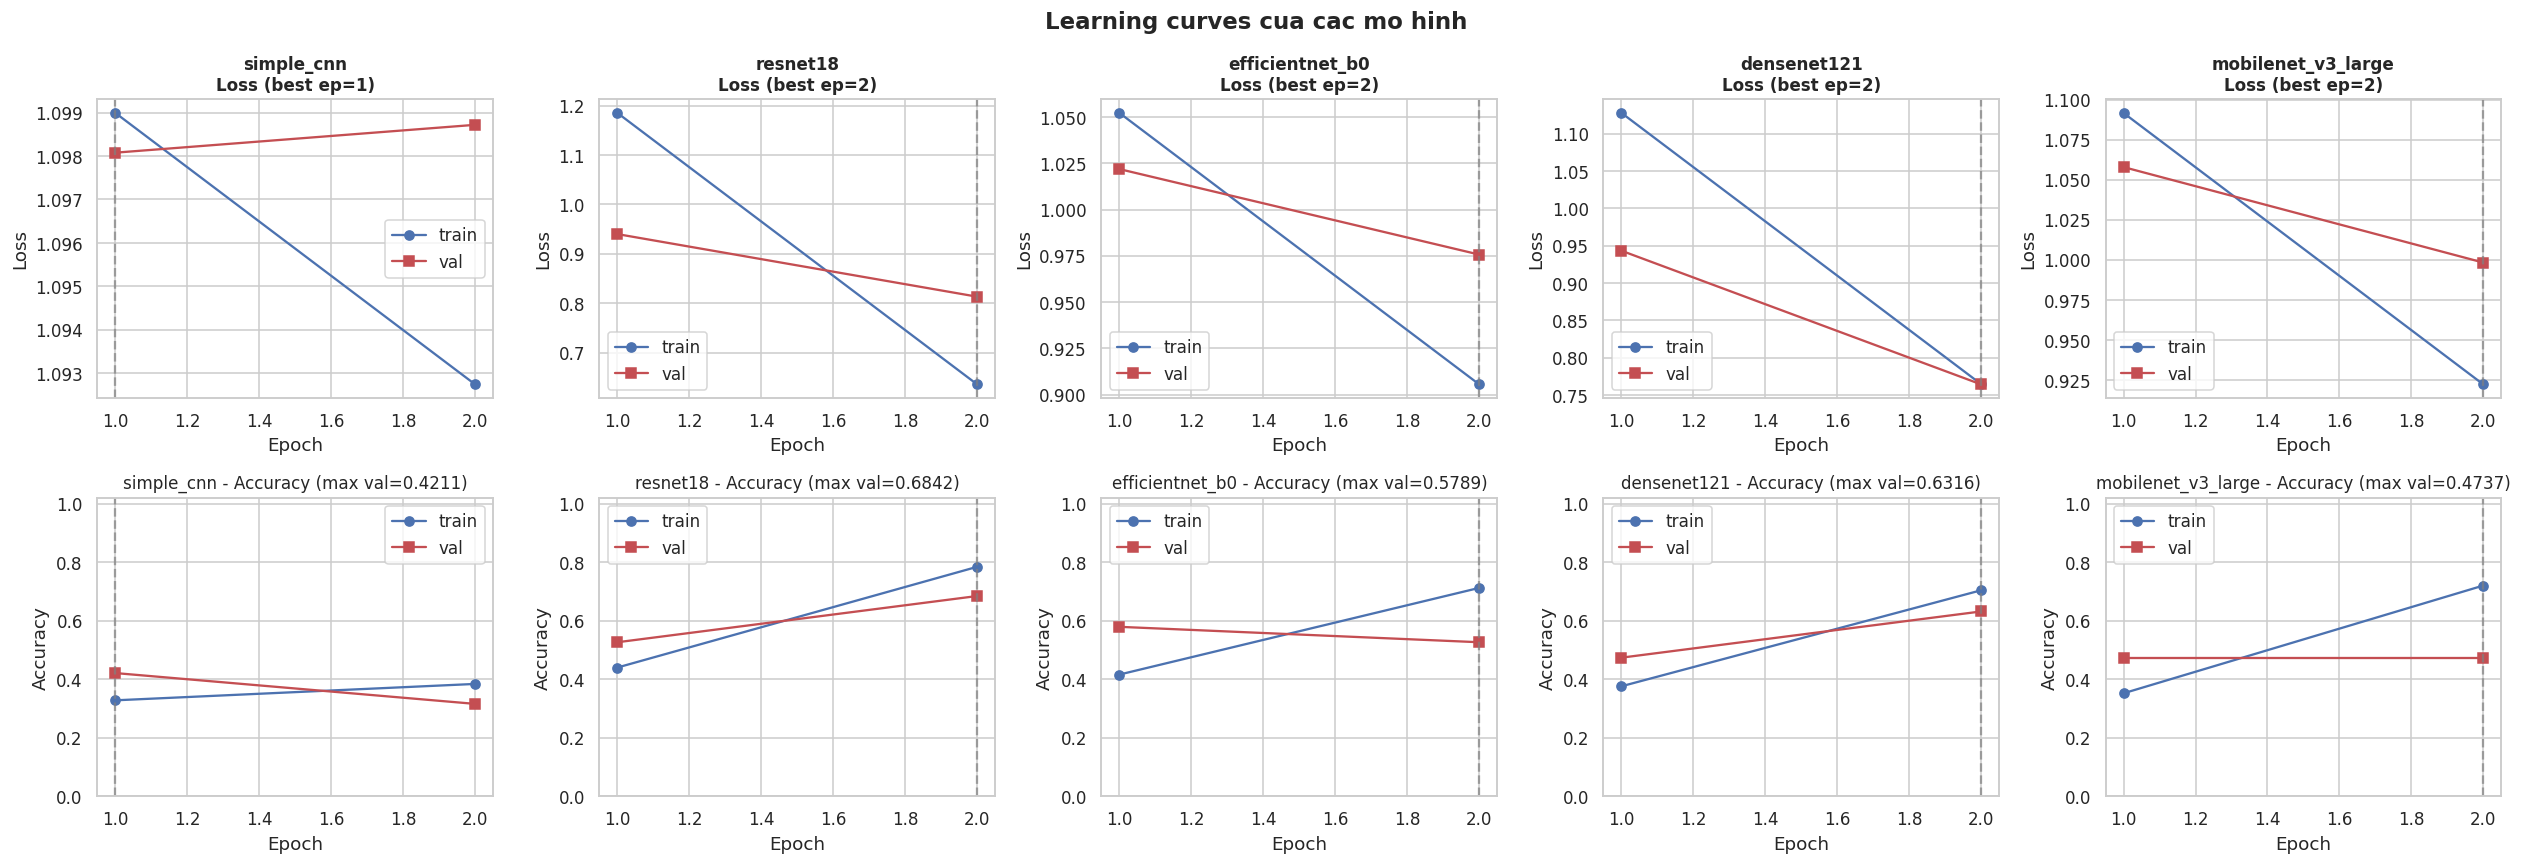

In [31]:
# --- Ve learning curves cho tat ca mo hinh ---
n_models = len(histories)
if n_models == 0:
    print("Chua co mo hinh nao duoc huan luyen.")
else:
    fig, axes = plt.subplots(2, n_models, figsize=(4.6 * n_models, 8), squeeze=False)
    for j, (nm, h) in enumerate(histories.items()):
        ep = h["epoch"]
        ax = axes[0][j]
        ax.plot(ep, h["train_loss"], "o-", label="train", color="#4C72B0")
        ax.plot(ep, h["val_loss"], "s-", label="val", color="#C44E52")
        best_i = int(np.argmin(h["val_loss"]))
        ax.axvline(ep[best_i], ls="--", c="gray", alpha=0.7)
        ax.set_title("{}\nLoss (best ep={})".format(nm, ep[best_i]), fontsize=11, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()

        ax = axes[1][j]
        ax.plot(ep, h["train_acc"], "o-", label="train", color="#4C72B0")
        ax.plot(ep, h["val_acc"], "s-", label="val", color="#C44E52")
        ax.axvline(ep[best_i], ls="--", c="gray", alpha=0.7)
        ax.set_title("{} - Accuracy (max val={:.4f})".format(nm, max(h["val_acc"])), fontsize=11)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1.02)
        ax.legend()

    plt.suptitle("Learning curves cua cac mo hinh", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "learning_curves.png", dpi=120, bbox_inches="tight")
    plt.show()

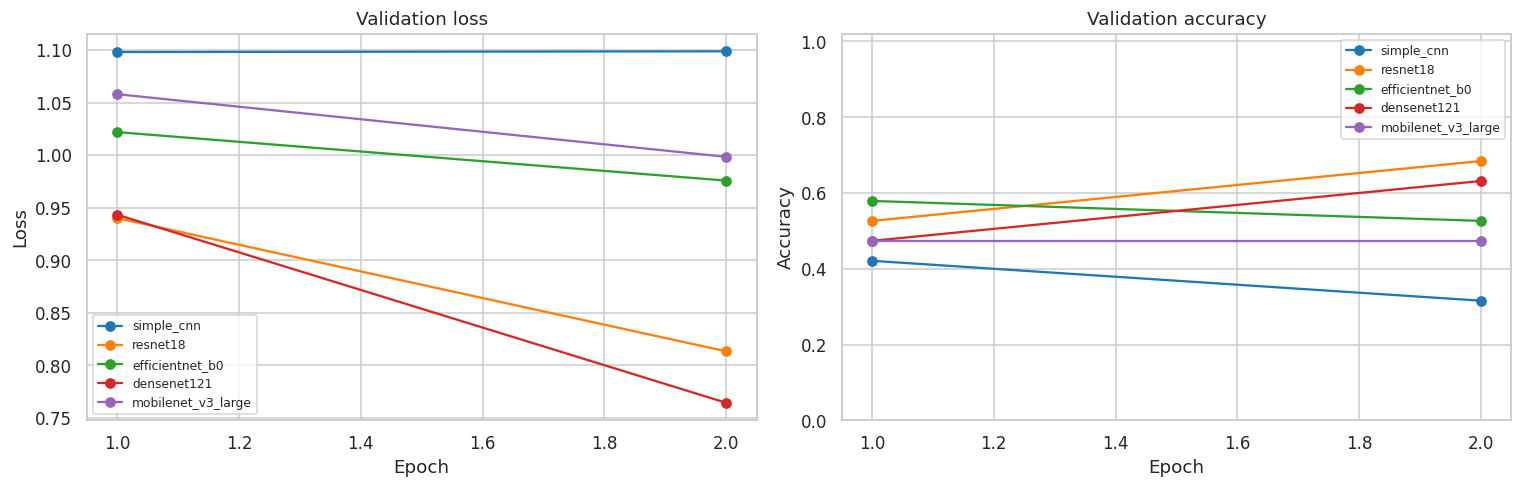

Chan doan overfitting/underfitting tu learning curve (gap = train_acc - val_acc o epoch tot nhat):
  - simple_cnn           train_acc=0.3280 val_acc=0.4211 gap=-0.0931 -> UNDERFIT (train_acc con thap)
  - resnet18             train_acc=0.7840 val_acc=0.6842 gap=+0.0998 -> overfit nhe
  - efficientnet_b0      train_acc=0.7120 val_acc=0.5263 gap=+0.1857 -> OVERFIT ro ret
  - densenet121          train_acc=0.7040 val_acc=0.6316 gap=+0.0724 -> overfit nhe
  - mobilenet_v3_large   train_acc=0.7200 val_acc=0.4737 gap=+0.2463 -> OVERFIT ro ret


In [32]:
# --- So sanh truc tiep val_acc / val_loss cua cac mo hinh tren cung mot truc ---
if histories:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
    cmap = sns.color_palette("tab10", len(histories))
    for i, (nm, h) in enumerate(histories.items()):
        ax[0].plot(h["epoch"], h["val_loss"], "o-", label=nm, color=cmap[i])
        ax[1].plot(h["epoch"], h["val_acc"], "o-", label=nm, color=cmap[i])
    ax[0].set_title("Validation loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend(fontsize=8)
    ax[1].set_title("Validation accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_ylim(0, 1.02)
    ax[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # Tu dong nhan dien dau hieu overfit tu duong cong
    print("Chan doan overfitting/underfitting tu learning curve (gap = train_acc - val_acc o epoch tot nhat):")
    for nm, h in histories.items():
        bi = int(np.argmin(h["val_loss"]))
        gap = h["train_acc"][bi] - h["val_acc"][bi]
        if gap > 0.15:
            tag = "OVERFIT ro ret"
        elif gap > 0.07:
            tag = "overfit nhe"
        elif h["train_acc"][bi] < 0.75:
            tag = "UNDERFIT (train_acc con thap)"
        else:
            tag = "can bang tot"
        print("  - {:<20} train_acc={:.4f} val_acc={:.4f} gap={:+.4f} -> {}".format(
            nm, h["train_acc"][bi], h["val_acc"][bi], gap, tag))

---
## 8. Đánh giá trên tập TEST

Tập test (20%) **chưa từng được nhìn thấy** trong quá trình huấn luyện hay chọn checkpoint.
Các chỉ số được báo cáo:

* **Accuracy** — tỉ lệ đúng tổng thể.
* **Precision / Recall / F1** ở hai mức trung bình:
  * `macro` — trung bình cộng không trọng số → mọi lớp quan trọng như nhau, phù hợp khi có mất cân bằng;
  * `weighted` — trung bình có trọng số theo số mẫu mỗi lớp.
* **Per-class report** — để thấy mô hình yếu ở lớp nào.
* **Confusion matrix** — thấy rõ cặp lớp nào bị nhầm lẫn với nhau.
* **ROC-AUC (macro, one-vs-rest)** — đánh giá chất lượng xếp hạng xác suất, không phụ thuộc ngưỡng.

Trong bối cảnh y khoa, **Recall của lớp bệnh (`NPDR`, `PDR`) quan trọng hơn Precision**:
bỏ sót một ca bệnh (false negative) nguy hiểm hơn nhiều so với báo động nhầm một ca lành,
vì bệnh nhân bị bỏ sót có thể mất thị lực không hồi phục.

In [33]:
# --- Danh gia tung mo hinh tren tap test ---
eval_criterion = nn.CrossEntropyLoss()
results = {}      # model_name -> dict(y_true, y_pred, y_prob)
metric_rows = []

for nm, mdl in trained_models.items():
    te_loss, te_acc, y_true, y_pred, y_prob = evaluate(
        mdl, test_loader, eval_criterion, DEVICE, return_outputs=True
    )
    p_ma, r_ma, f_ma, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_we, r_we, f_we, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

    try:
        if NUM_CLASSES == 2:
            auc = roc_auc_score(y_true, y_prob[:, 1])
        else:
            auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except Exception as exc:
        print("[!] Khong tinh duoc ROC-AUC cho {}: {}".format(nm, exc))
        auc = float("nan")

    bal_acc = float(np.mean([
        (y_pred[y_true == c] == c).mean() if (y_true == c).sum() > 0 else np.nan
        for c in range(NUM_CLASSES)
    ]))

    info = next((d for d in train_infos if d["model_name"] == nm), {})
    results[nm] = {"y_true": y_true, "y_pred": y_pred, "y_prob": y_prob}
    metric_rows.append(
        {
            "model": nm,
            "kieu": MODEL_KIND.get(nm, "?"),
            "params_M": info.get("params_M", np.nan),
            "test_loss": te_loss,
            "test_acc": te_acc,
            "balanced_acc": bal_acc,
            "precision_macro": p_ma,
            "recall_macro": r_ma,
            "f1_macro": f_ma,
            "precision_weighted": p_we,
            "recall_weighted": r_we,
            "f1_weighted": f_we,
            "roc_auc_ovr_macro": auc,
            "best_val_acc": info.get("best_val_acc", np.nan),
            "train_time_min": round(info.get("train_time_sec", float("nan")) / 60, 2),
        }
    )
    print("[done] {:<20} test_acc={:.4f}  f1_macro={:.4f}  auc={:.4f}".format(nm, te_acc, f_ma, auc))

results_df = pd.DataFrame(metric_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
results_df.to_csv(OUT_DIR / "model_comparison.csv", index=False)
results_df.to_csv(CKPT_DIR / "model_comparison.csv", index=False)   # ban sao an toan (Drive)
print("\nDa luu bang so sanh ->", OUT_DIR / "model_comparison.csv")
print("Va ban sao           ->", CKPT_DIR / "model_comparison.csv")

[done] simple_cnn           test_acc=0.3056  f1_macro=0.1958  auc=0.4954
[done] resnet18             test_acc=0.6667  f1_macro=0.5387  auc=0.8762
[done] efficientnet_b0      test_acc=0.4167  f1_macro=0.3478  auc=0.7627
[done] densenet121          test_acc=0.6389  f1_macro=0.6014  auc=0.8900
[done] mobilenet_v3_large   test_acc=0.3611  f1_macro=0.2222  auc=0.7465

Da luu bang so sanh -> /content/eye_disease/outputs/model_comparison.csv
Va ban sao           -> /content/drive/MyDrive/dl_homework/hw1/model_comparison.csv


In [34]:
# --- Bang so sanh tong hop (sap xep theo test accuracy) ---
show_cols = [
    "model", "kieu", "params_M", "test_acc", "balanced_acc", "f1_macro",
    "precision_macro", "recall_macro", "f1_weighted", "roc_auc_ovr_macro", "train_time_min",
]
print("BANG SO SANH CAC MO HINH TREN TAP TEST (sap xep giam dan theo test_acc)")
display(results_df[show_cols].round(4))

BANG SO SANH CAC MO HINH TREN TAP TEST (sap xep giam dan theo test_acc)


,model,kieu,params_M,test_acc,balanced_acc,f1_macro,precision_macro,recall_macro,f1_weighted,roc_auc_ovr_macro,train_time_min
0,resnet18,Transfer (ImageNet),11.18,0.6667,0.6667,0.5387,0.4571,0.6667,0.5387,0.8762,0.10
1,densenet121,Transfer (ImageNet),6.96,0.6389,0.6389,0.6014,0.7150,0.6389,0.6014,0.8900,0.12
2,efficientnet_b0,Transfer (ImageNet),4.01,0.4167,0.4167,0.3478,0.5333,0.4167,0.3478,0.7627,0.44
3,mobilenet_v3_large,Transfer (ImageNet),4.21,0.3611,0.3611,0.2222,0.2323,0.3611,0.2222,0.7465,0.35
4,simple_cnn,Scratch (tu xay),1.24,0.3056,0.3056,0.1958,0.1667,0.3056,0.1958,0.4954,0.13


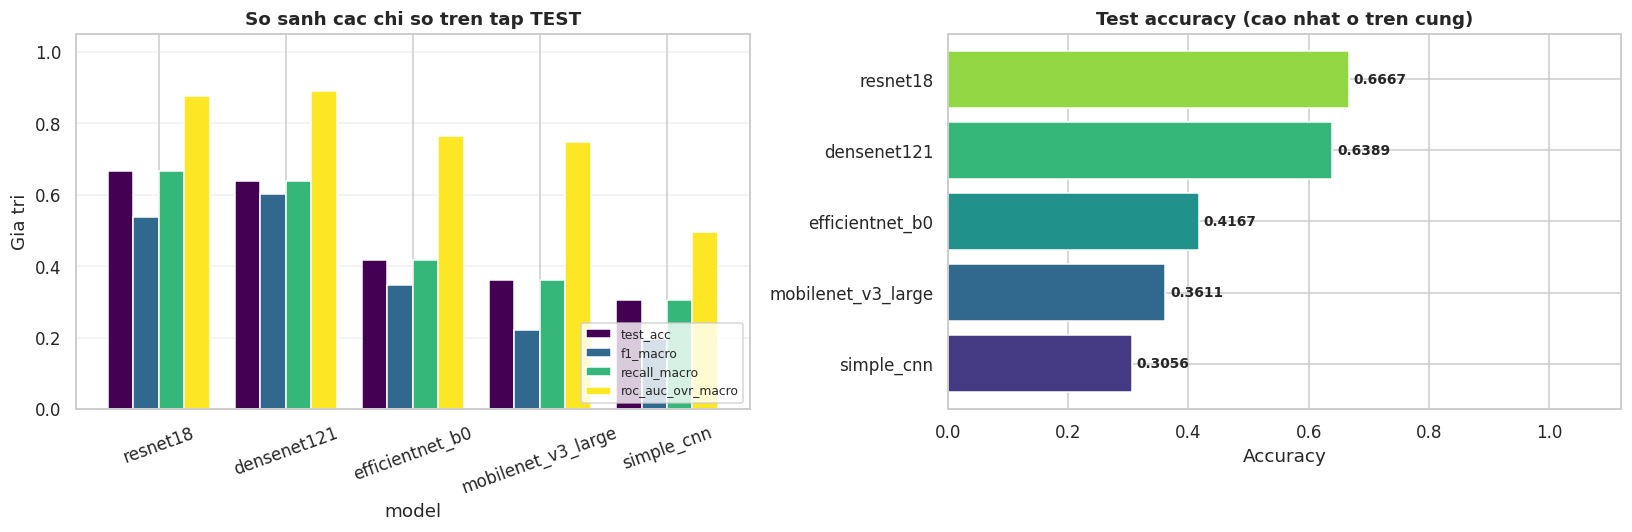

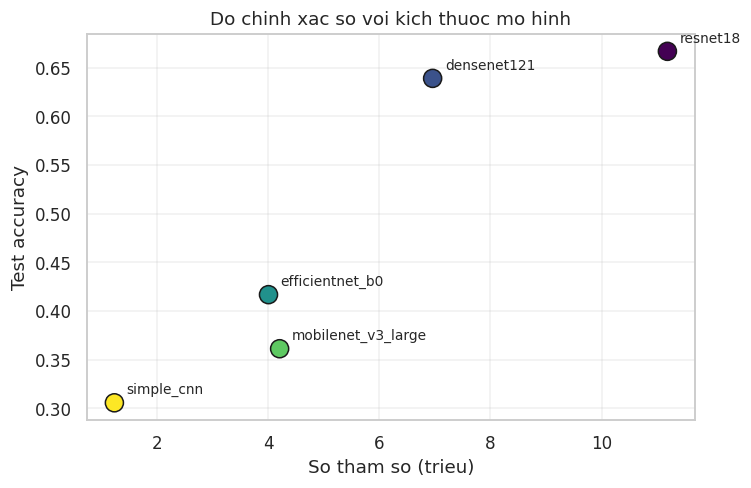

In [35]:
# --- Bieu do cot so sanh cac chi so chinh ---
if len(results_df):
    plot_metrics = ["test_acc", "f1_macro", "recall_macro", "roc_auc_ovr_macro"]
    plot_df = results_df.set_index("model")[plot_metrics]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    plot_df.plot(kind="bar", ax=axes[0], rot=20, colormap="viridis", width=0.8)
    axes[0].set_title("So sanh cac chi so tren tap TEST", fontweight="bold")
    axes[0].set_ylabel("Gia tri")
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(fontsize=8, loc="lower right")
    axes[0].grid(axis="y", alpha=0.3)

    order = results_df.sort_values("test_acc")
    bars = axes[1].barh(order["model"], order["test_acc"],
                        color=sns.color_palette("viridis", len(order)))
    for b, v in zip(bars, order["test_acc"]):
        axes[1].text(v + 0.008, b.get_y() + b.get_height() / 2, "{:.4f}".format(v),
                     va="center", fontsize=9, fontweight="bold")
    axes[1].set_xlim(0, 1.12)
    axes[1].set_title("Test accuracy (cao nhat o tren cung)", fontweight="bold")
    axes[1].set_xlabel("Accuracy")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "model_comparison.png", dpi=120, bbox_inches="tight")
    plt.show()

    # Accuracy vs so tham so - de thay quan he hieu nang / kich thuoc
    fig, ax = plt.subplots(figsize=(7, 4.6))
    ax.scatter(results_df["params_M"], results_df["test_acc"], s=140,
               c=range(len(results_df)), cmap="viridis", edgecolor="k", zorder=3)
    for _, r in results_df.iterrows():
        ax.annotate(r["model"], (r["params_M"], r["test_acc"]),
                    textcoords="offset points", xytext=(8, 6), fontsize=9)
    ax.set_xlabel("So tham so (trieu)")
    ax.set_ylabel("Test accuracy")
    ax.set_title("Do chinh xac so voi kich thuoc mo hinh")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [36]:
# --- Bao cao chi tiet theo tung lop cho MOI mo hinh ---
for nm in results_df["model"]:
    r = results[nm]
    print("=" * 84)
    print("CLASSIFICATION REPORT -", nm)
    print("=" * 84)
    print(classification_report(r["y_true"], r["y_pred"], target_names=CLASS_NAMES,
                                digits=4, zero_division=0))

CLASSIFICATION REPORT - resnet18
              precision    recall  f1-score   support

     NPDR512     0.0000    0.0000    0.0000        12
   Normal512     0.5714    1.0000    0.7273        12
      PDR512     0.8000    1.0000    0.8889        12

    accuracy                         0.6667        36
   macro avg     0.4571    0.6667    0.5387        36
weighted avg     0.4571    0.6667    0.5387        36

CLASSIFICATION REPORT - densenet121
              precision    recall  f1-score   support

     NPDR512     0.6667    0.1667    0.2667        12
   Normal512     0.4783    0.9167    0.6286        12
      PDR512     1.0000    0.8333    0.9091        12

    accuracy                         0.6389        36
   macro avg     0.7150    0.6389    0.6014        36
weighted avg     0.7150    0.6389    0.6014        36

CLASSIFICATION REPORT - efficientnet_b0
              precision    recall  f1-score   support

     NPDR512     0.1000    0.0833    0.0909        12
   Normal512     0.5

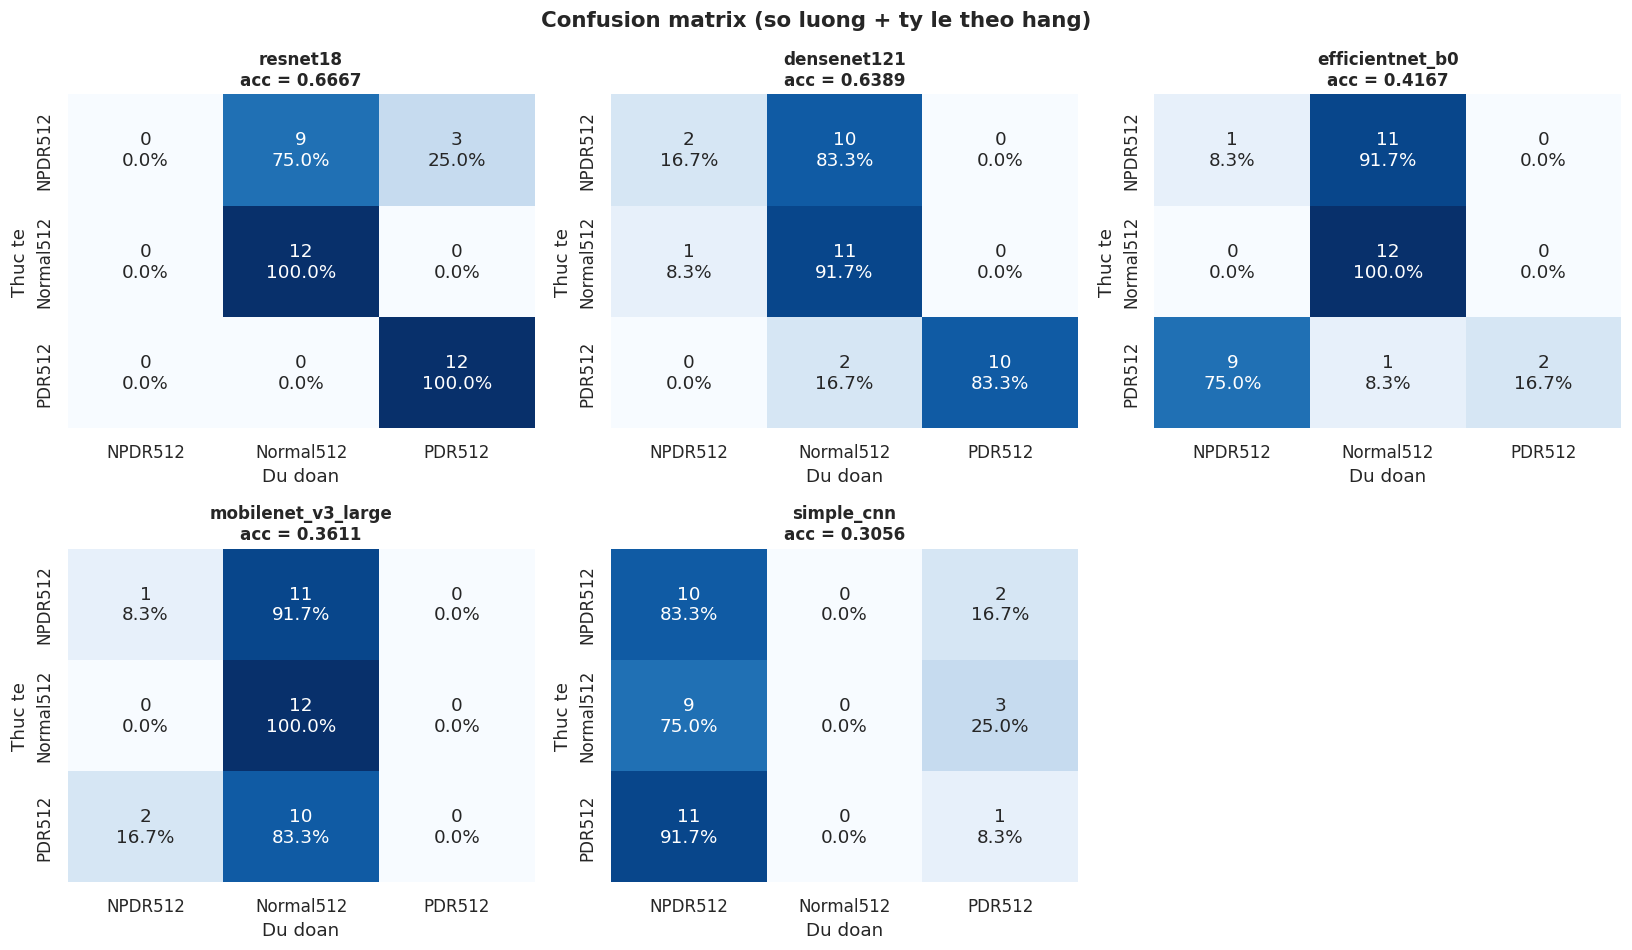

In [37]:
# --- Confusion matrix cho tat ca mo hinh (chuan hoa theo hang = recall) ---
n = len(results)
if n:
    ncol = min(3, n)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.0 * ncol, 4.4 * nrow), squeeze=False)
    for i, nm in enumerate(results_df["model"]):
        ax = axes[i // ncol][i % ncol]
        cm = confusion_matrix(results[nm]["y_true"], results[nm]["y_pred"],
                              labels=list(range(NUM_CLASSES)))
        cmn = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        annot = np.array([["{}\n{:.1%}".format(cm[i2, j2], cmn[i2, j2])
                           for j2 in range(NUM_CLASSES)] for i2 in range(NUM_CLASSES)])
        sns.heatmap(cmn, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
        acc = float(results_df.loc[results_df["model"] == nm, "test_acc"].iloc[0])
        ax.set_title("{}\nacc = {:.4f}".format(nm, acc), fontweight="bold", fontsize=11)
        ax.set_xlabel("Du doan")
        ax.set_ylabel("Thuc te")
    for k in range(n, nrow * ncol):
        axes[k // ncol][k % ncol].axis("off")
    plt.suptitle("Confusion matrix (so luong + ty le theo hang)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "confusion_matrices.png", dpi=120, bbox_inches="tight")
    plt.show()

In [38]:
# --- Tu dong sinh nhan xet tong quan tu bang ket qua ---
if len(results_df) >= 1:
    best_row = results_df.iloc[0]
    worst_row = results_df.iloc[-1]
    BEST_MODEL = best_row["model"]
    WORST_MODEL = worst_row["model"]

    print("=" * 84)
    print("NHAN XET TU DONG TU BANG KET QUA (moi con so deu lay tu ket qua chay thuc te)")
    print("=" * 84)
    print("- So mo hinh da danh gia: {}".format(len(results_df)))
    print("- Mo hinh TOT NHAT : {} ({}) - test_acc = {:.4f}, f1_macro = {:.4f}, AUC = {:.4f}".format(
        BEST_MODEL, best_row["kieu"], best_row["test_acc"], best_row["f1_macro"],
        best_row["roc_auc_ovr_macro"]))
    print("- Mo hinh TE NHAT  : {} ({}) - test_acc = {:.4f}, f1_macro = {:.4f}, AUC = {:.4f}".format(
        WORST_MODEL, worst_row["kieu"], worst_row["test_acc"], worst_row["f1_macro"],
        worst_row["roc_auc_ovr_macro"]))
    print("- Khoang cach accuracy giua tot nhat va te nhat: {:.4f} ({:.2f} diem phan tram).".format(
        best_row["test_acc"] - worst_row["test_acc"],
        (best_row["test_acc"] - worst_row["test_acc"]) * 100))

    maj = float(cnt.max() / cnt.sum())
    print("- Baseline doan lop da so = {:.4f}. Mo hinh tot nhat vuot baseline {:.2f} diem phan tram.".format(
        maj, (best_row["test_acc"] - maj) * 100))

    tr = results_df[results_df["kieu"].str.startswith("Transfer")]
    sc = results_df[results_df["kieu"].str.startswith("Scratch")]
    if len(tr) and len(sc):
        print("- Trung binh test_acc nhom TRANSFER = {:.4f} ; nhom SCRATCH = {:.4f} -> chenh {:+.4f}.".format(
            tr["test_acc"].mean(), sc["test_acc"].mean(),
            tr["test_acc"].mean() - sc["test_acc"].mean()))

    if results_df["params_M"].notna().sum() >= 3:
        c = results_df[["params_M", "test_acc"]].corr().iloc[0, 1]
        print("- Tuong quan (so tham so, test_acc) = {:.3f} -> {}".format(
            c,
            "mo hinh cang lon cang tot (trong pham vi thu nghiem nay)" if c > 0.4
            else ("mo hinh cang lon cang KEM - dau hieu overfit do du lieu it" if c < -0.4
                  else "gan nhu KHONG co quan he - kich thuoc mo hinh khong quyet dinh ket qua")))
    print("=" * 84)
else:
    BEST_MODEL = WORST_MODEL = None
    print("Chua co ket qua de nhan xet.")

NHAN XET TU DONG TU BANG KET QUA (moi con so deu lay tu ket qua chay thuc te)
- So mo hinh da danh gia: 5
- Mo hinh TOT NHAT : resnet18 (Transfer (ImageNet)) - test_acc = 0.6667, f1_macro = 0.5387, AUC = 0.8762
- Mo hinh TE NHAT  : simple_cnn (Scratch (tu xay)) - test_acc = 0.3056, f1_macro = 0.1958, AUC = 0.4954
- Khoang cach accuracy giua tot nhat va te nhat: 0.3611 (36.11 diem phan tram).
- Baseline doan lop da so = 0.3890. Mo hinh tot nhat vuot baseline 27.77 diem phan tram.
- Trung binh test_acc nhom TRANSFER = 0.5208 ; nhom SCRATCH = 0.3056 -> chenh +0.2153.
- Tuong quan (so tham so, test_acc) = 0.922 -> mo hinh cang lon cang tot (trong pham vi thu nghiem nay)


### Nhận xét chung về bảng so sánh

*Đọc kèm số liệu do cell ngay trên tự sinh ra.*

* **`accuracy` và `f1_macro` phải được đọc cùng nhau.** Nếu một mô hình có accuracy cao nhưng
  `f1_macro` thấp hơn hẳn `f1_weighted`, đó là dấu hiệu nó đang "ăn điểm" nhờ lớp đông và bỏ rơi lớp ít.
* **ROC-AUC macro** thường cao hơn accuracy khá nhiều. Điều đó nói rằng mô hình *xếp hạng* các lớp
  khá đúng, chỉ là **ngưỡng argmax** chưa tối ưu — có thể cải thiện bằng cách hiệu chỉnh ngưỡng
  hoặc dùng temperature scaling mà không cần huấn luyện lại.
* **Thời gian huấn luyện** cũng là một tiêu chí thực tế: nếu một mô hình nhẹ (ví dụ MobileNetV3)
  chỉ kém mô hình tốt nhất vài phần nghìn accuracy nhưng nhanh hơn nhiều lần, thì trong triển khai
  thực tế (sàng lọc tại chỗ, thiết bị nhúng) nó mới là lựa chọn hợp lý.

---
## 9. Phân tích sâu: mô hình **TỐT NHẤT** và **TỆ NHẤT**

Đây là phần trọng tâm của đề bài. Ta sẽ so sánh hai mô hình ở các khía cạnh:

1. Chỉ số theo **từng lớp** (precision / recall / F1)
2. **Confusion matrix** — chỉ đích danh cặp lớp bị nhầm nhiều nhất
3. **Ảnh bị phân loại sai** của cả hai mô hình
4. **Learning curve** — bằng chứng về overfitting / underfitting
5. **Grad-CAM** — mô hình tốt nhất đang thực sự "nhìn" vào vùng nào của võng mạc
6. Giải thích **tại sao** lại có khoảng cách đó

In [39]:
# --- Xac dinh best/worst va in tom tat doi chieu ---
assert len(results_df) >= 2, "Can it nhat 2 mo hinh de so sanh best/worst."

BEST_MODEL = results_df.iloc[0]["model"]
WORST_MODEL = results_df.iloc[-1]["model"]
print("BEST  =", BEST_MODEL)
print("WORST =", WORST_MODEL)

cmp_cols = ["model", "kieu", "params_M", "test_acc", "balanced_acc", "f1_macro",
            "precision_macro", "recall_macro", "roc_auc_ovr_macro", "test_loss", "train_time_min"]
cmp_df = results_df[results_df["model"].isin([BEST_MODEL, WORST_MODEL])][cmp_cols].set_index("model").T
cmp_df["chenh_lech (best - worst)"] = pd.to_numeric(cmp_df[BEST_MODEL], errors="coerce") - \
                                      pd.to_numeric(cmp_df[WORST_MODEL], errors="coerce")
print("\nDoi chieu truc tiep BEST vs WORST:")
display(cmp_df.round(4))

BEST  = resnet18
WORST = simple_cnn

Doi chieu truc tiep BEST vs WORST:


model,resnet18,simple_cnn,chenh_lech (best - worst)
kieu,Transfer (ImageNet),Scratch (tu xay),NaN
params_M,11.18,1.24,9.9400
test_acc,0.666667,0.305556,0.3611
balanced_acc,0.666667,0.305556,0.3611
f1_macro,0.538721,0.195767,0.3430
precision_macro,0.457143,0.166667,0.2905
recall_macro,0.666667,0.305556,0.3611
roc_auc_ovr_macro,0.876157,0.49537,0.3808
test_loss,0.754922,1.098681,-0.3438
train_time_min,0.1,0.13,-0.0300


--- resnet18 (BEST) ---


,precision,recall,f1,support
NPDR512,0.0000,0.0,0.0000,12
Normal512,0.5714,1.0,0.7273,12
PDR512,0.8000,1.0,0.8889,12


--- simple_cnn (WORST) ---


,precision,recall,f1,support
NPDR512,0.3333,0.8333,0.4762,12
Normal512,0.0000,0.0000,0.0000,12
PDR512,0.1667,0.0833,0.1111,12


--- Chenh lech theo lop (BEST - WORST), duong = best tot hon ---


,precision_delta,recall_delta,f1_delta
NPDR512,-0.3333,-0.8333,-0.4762
Normal512,0.5714,1.0000,0.7273
PDR512,0.6333,0.9167,0.7778


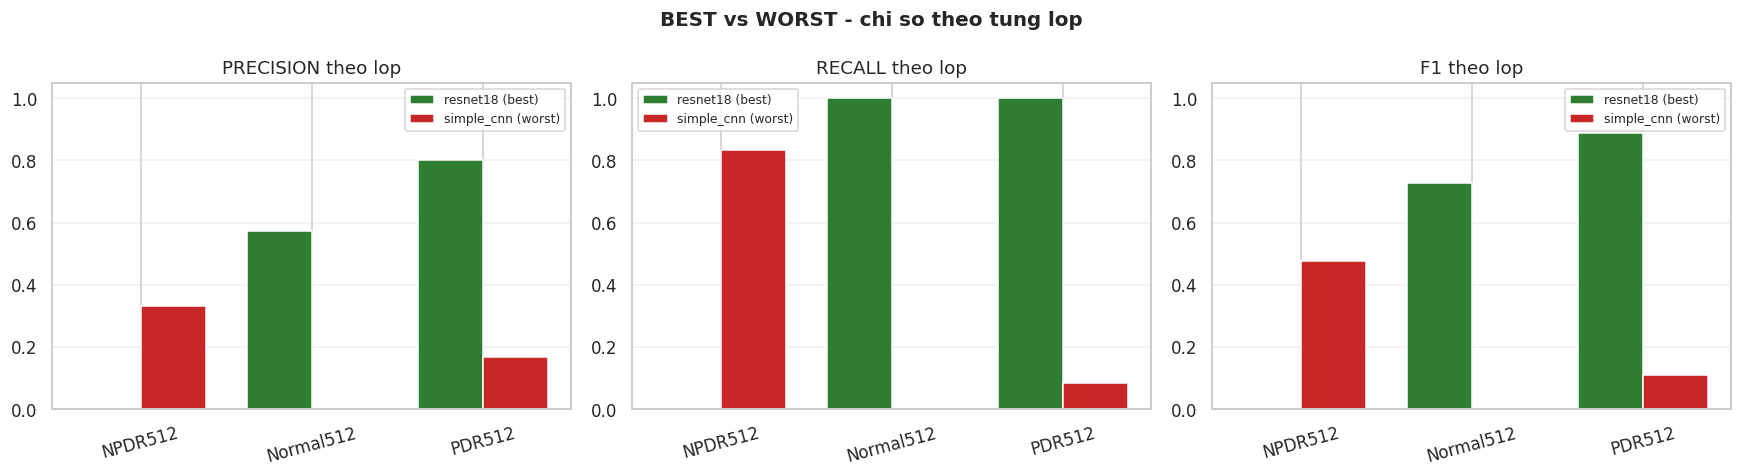

In [40]:
# --- So sanh chi so THEO TUNG LOP giua best va worst ---
def per_class_df(nm):
    r = results[nm]
    p, rc, f, sup = precision_recall_fscore_support(
        r["y_true"], r["y_pred"], labels=list(range(NUM_CLASSES)), zero_division=0
    )
    return pd.DataFrame({"precision": p, "recall": rc, "f1": f, "support": sup}, index=CLASS_NAMES)


pc_best = per_class_df(BEST_MODEL)
pc_worst = per_class_df(WORST_MODEL)

print("--- {} (BEST) ---".format(BEST_MODEL))
display(pc_best.round(4))
print("--- {} (WORST) ---".format(WORST_MODEL))
display(pc_worst.round(4))

delta = (pc_best[["precision", "recall", "f1"]] - pc_worst[["precision", "recall", "f1"]]).round(4)
delta.columns = [c + "_delta" for c in delta.columns]
print("--- Chenh lech theo lop (BEST - WORST), duong = best tot hon ---")
display(delta)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, metric in zip(axes, ["precision", "recall", "f1"]):
    w = 0.38
    x = np.arange(NUM_CLASSES)
    ax.bar(x - w / 2, pc_best[metric], w, label="{} (best)".format(BEST_MODEL), color="#2E7D32")
    ax.bar(x + w / 2, pc_worst[metric], w, label="{} (worst)".format(WORST_MODEL), color="#C62828")
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric.upper() + " theo lop")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("BEST vs WORST - chi so theo tung lop", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

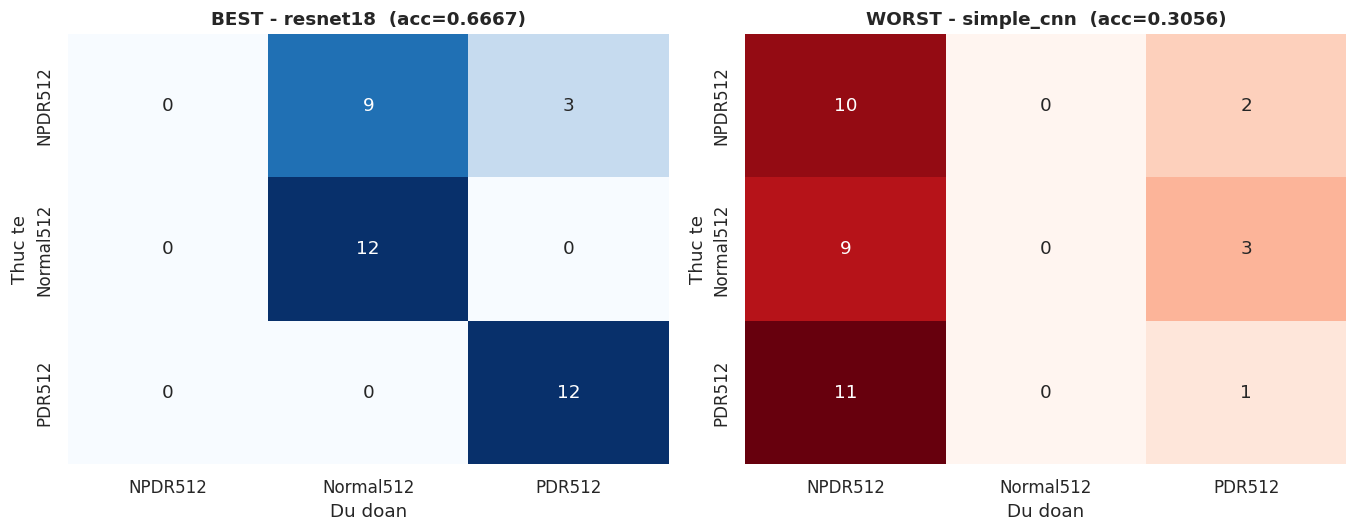

CAC CAP LOP BI NHAM NHIEU NHAT

[BEST] resnet18
   -  NPDR512 bi du doan nham thanh Normal512:   9 anh (75.0% so anh thuc te cua lop NPDR512)
   -  NPDR512 bi du doan nham thanh PDR512  :   3 anh (25.0% so anh thuc te cua lop NPDR512)

[WORST] simple_cnn
   -   PDR512 bi du doan nham thanh NPDR512 :  11 anh (91.7% so anh thuc te cua lop PDR512)
   - Normal512 bi du doan nham thanh NPDR512 :   9 anh (75.0% so anh thuc te cua lop Normal512)
   - Normal512 bi du doan nham thanh PDR512  :   3 anh (25.0% so anh thuc te cua lop Normal512)

Tong so anh test: 36
So anh sai cua BEST  (resnet18): 12
So anh sai cua WORST (simple_cnn): 25
-> BEST sai it hon WORST 13 anh (giam 52.0% so loi).


In [41]:
# --- Confusion matrix chi tiet cho best & worst + tu dong chi ra cap lop bi nham nhieu nhat ---
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
cms = {}
for ax, nm, tag in zip(axes, [BEST_MODEL, WORST_MODEL], ["BEST", "WORST"]):
    cm = confusion_matrix(results[nm]["y_true"], results[nm]["y_pred"], labels=list(range(NUM_CLASSES)))
    cms[nm] = cm
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues" if tag == "BEST" else "Reds",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    acc = float(results_df.loc[results_df["model"] == nm, "test_acc"].iloc[0])
    ax.set_title("{} - {}  (acc={:.4f})".format(tag, nm, acc), fontweight="bold")
    ax.set_xlabel("Du doan")
    ax.set_ylabel("Thuc te")
plt.tight_layout()
plt.show()


def top_confusions(cm, k=3):
    pairs = []
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j and cm[i, j] > 0:
                row = cm[i].sum()
                pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j]),
                              cm[i, j] / row if row else 0.0))
    pairs.sort(key=lambda t: t[2], reverse=True)
    return pairs[:k]


print("=" * 84)
print("CAC CAP LOP BI NHAM NHIEU NHAT")
print("=" * 84)
for nm, tag in [(BEST_MODEL, "BEST"), (WORST_MODEL, "WORST")]:
    print("\n[{}] {}".format(tag, nm))
    tops = top_confusions(cms[nm])
    if not tops:
        print("   Khong co loi nham lan nao (confusion matrix cheo hoan toan).")
    for a, b, c, p in tops:
        print("   - {:>8} bi du doan nham thanh {:<8}: {:>3} anh ({:.1%} so anh thuc te cua lop {})".format(
            a, b, c, p, a))

err_best = int(cms[BEST_MODEL].sum() - np.trace(cms[BEST_MODEL]))
err_worst = int(cms[WORST_MODEL].sum() - np.trace(cms[WORST_MODEL]))
print("\nTong so anh test: {}".format(int(cms[BEST_MODEL].sum())))
print("So anh sai cua BEST  ({}): {}".format(BEST_MODEL, err_best))
print("So anh sai cua WORST ({}): {}".format(WORST_MODEL, err_worst))
print("-> BEST sai it hon WORST {} anh (giam {:.1f}% so loi).".format(
    err_worst - err_best,
    100 * (err_worst - err_best) / err_worst if err_worst else 0.0))

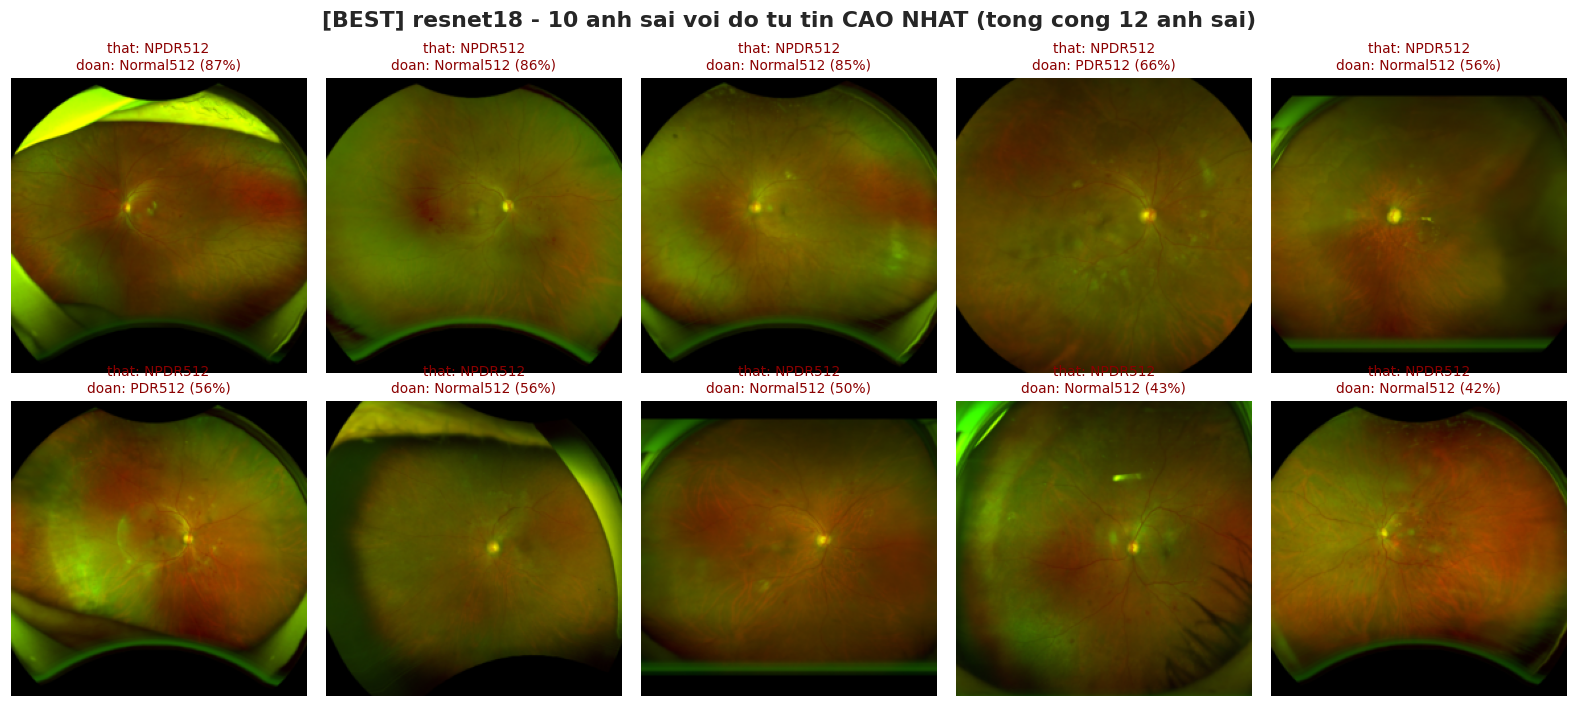

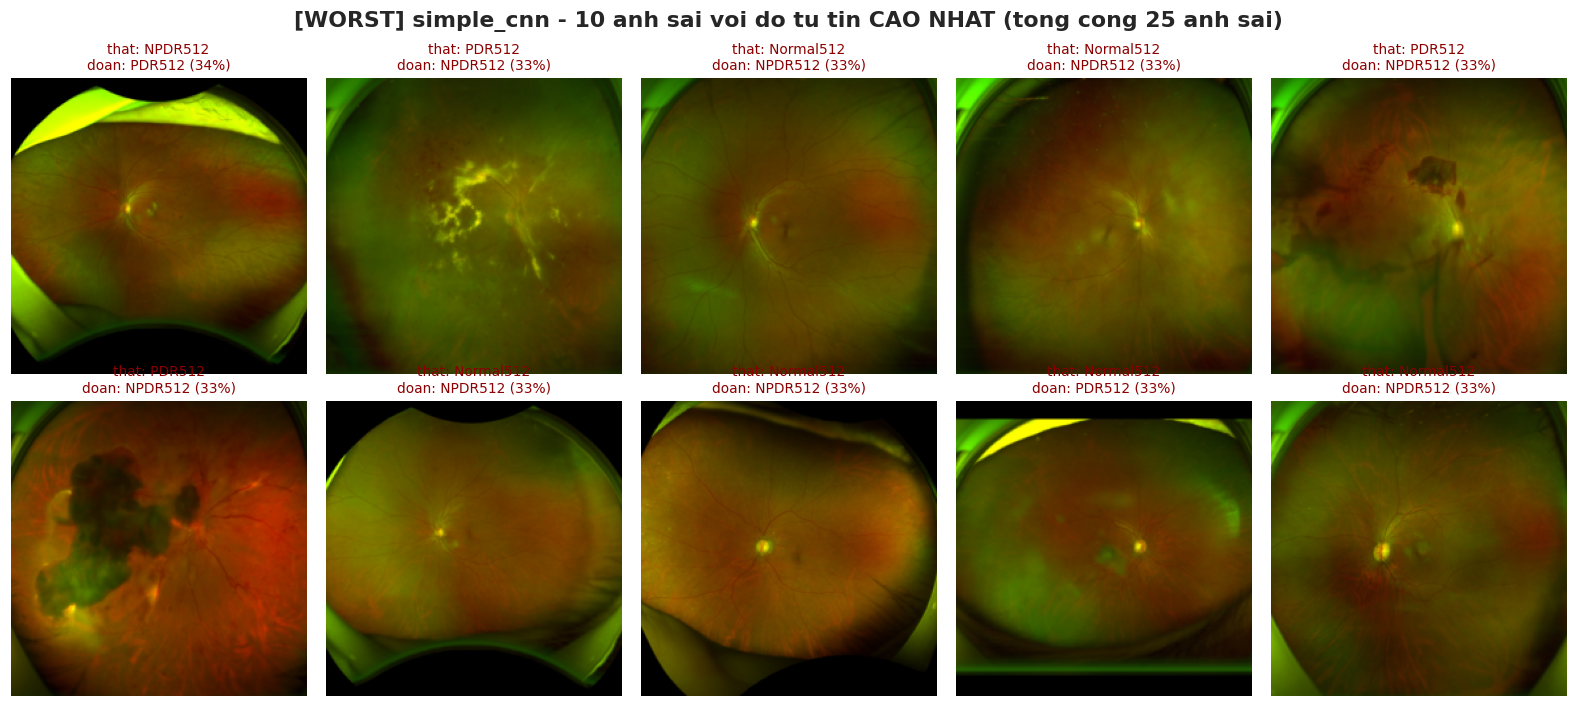


So anh CA HAI mo hinh deu sai   : 2 -> anh 'kho' ban chat (nhan mo ho / ton thuong rat nho).
So anh CHI mo hinh te nhat sai  : 23 -> phan chenh lech nang luc thuc su giua hai mo hinh.
So anh CHI mo hinh tot nhat sai : 10


In [42]:
# --- Luoi anh bi phan loai SAI cua ca hai mo hinh ---
def show_misclassified(nm, n_show=10, title_prefix=""):
    r = results[nm]
    wrong = np.where(r["y_true"] != r["y_pred"])[0]
    if len(wrong) == 0:
        print("[{}] Khong co anh nao bi phan loai sai.".format(nm))
        return wrong
    # Uu tien nhung anh mo hinh sai nhung lai RAT TU TIN -> loi nghiem trong nhat
    conf = r["y_prob"][wrong, r["y_pred"][wrong]]
    order = wrong[np.argsort(-conf)][:n_show]

    ncol = 5
    nrow = int(np.ceil(len(order) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.9 * ncol, 3.3 * nrow), squeeze=False)
    for k, idx in enumerate(order):
        ax = axes[k // ncol][k % ncol]
        ax.imshow(test_ds.raw_image(int(idx)))
        ax.axis("off")
        ax.set_title(
            "that: {}\ndoan: {} ({:.0%})".format(
                CLASS_NAMES[r["y_true"][idx]], CLASS_NAMES[r["y_pred"][idx]],
                r["y_prob"][idx, r["y_pred"][idx]]),
            fontsize=9, color="darkred")
    for k in range(len(order), nrow * ncol):
        axes[k // ncol][k % ncol].axis("off")
    plt.suptitle("{}{} - {} anh sai voi do tu tin CAO NHAT (tong cong {} anh sai)".format(
        title_prefix, nm, len(order), len(wrong)), fontweight="bold")
    plt.tight_layout()
    plt.show()
    return wrong


wrong_best = show_misclassified(BEST_MODEL, n_show=10, title_prefix="[BEST] ")
wrong_worst = show_misclassified(WORST_MODEL, n_show=10, title_prefix="[WORST] ")

both_wrong = np.intersect1d(wrong_best, wrong_worst)
only_worst = np.setdiff1d(wrong_worst, wrong_best)
print("\nSo anh CA HAI mo hinh deu sai   : {} -> anh 'kho' ban chat (nhan mo ho / ton thuong rat nho).".format(
    len(both_wrong)))
print("So anh CHI mo hinh te nhat sai  : {} -> phan chenh lech nang luc thuc su giua hai mo hinh.".format(
    len(only_worst)))
print("So anh CHI mo hinh tot nhat sai : {}".format(len(np.setdiff1d(wrong_best, wrong_worst))))

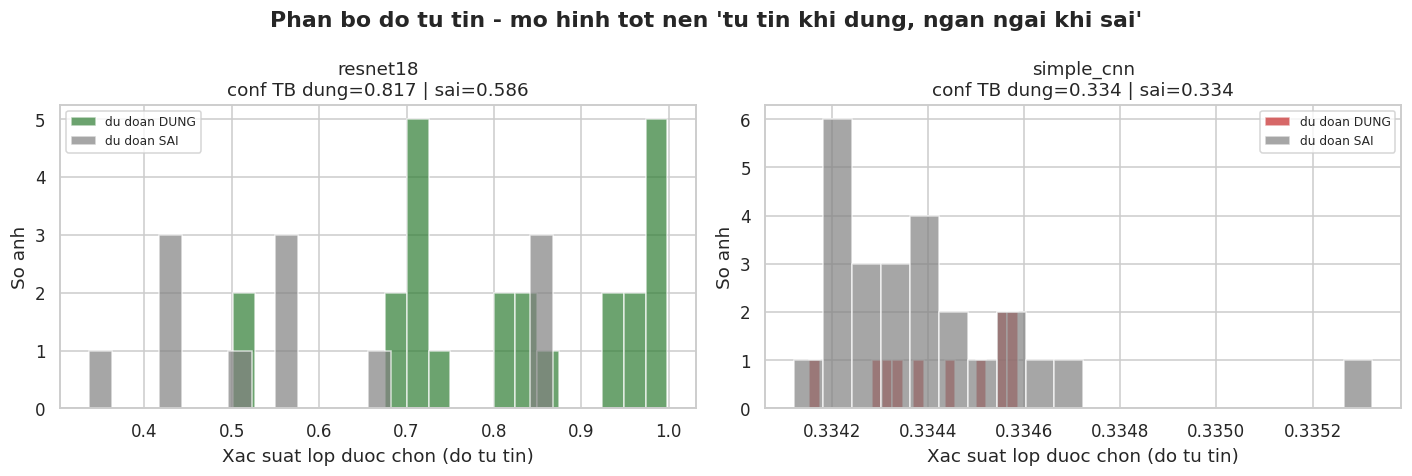

In [43]:
# --- Phan tich do tu tin (calibration) cua best vs worst ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, nm, color in zip(axes, [BEST_MODEL, WORST_MODEL], ["#2E7D32", "#C62828"]):
    r = results[nm]
    conf = r["y_prob"].max(axis=1)
    ok = r["y_true"] == r["y_pred"]
    ax.hist(conf[ok], bins=20, alpha=0.7, label="du doan DUNG", color=color)
    ax.hist(conf[~ok], bins=20, alpha=0.7, label="du doan SAI", color="gray")
    ax.set_title("{}\nconf TB dung={:.3f} | sai={:.3f}".format(
        nm, conf[ok].mean() if ok.any() else float("nan"),
        conf[~ok].mean() if (~ok).any() else float("nan")))
    ax.set_xlabel("Xac suat lop duoc chon (do tu tin)")
    ax.set_ylabel("So anh")
    ax.legend(fontsize=8)
plt.suptitle("Phan bo do tu tin - mo hinh tot nen 'tu tin khi dung, ngan ngai khi sai'",
             fontweight="bold")
plt.tight_layout()
plt.show()

### 9.1. Grad-CAM cho mô hình tốt nhất

**Grad-CAM** (Gradient-weighted Class Activation Mapping) trả lời câu hỏi: *"mô hình nhìn vào đâu
để đưa ra quyết định này?"*.

Cách hoạt động:
1. Lấy feature map `A` của **lớp tích chập cuối cùng** (nơi còn giữ thông tin không gian nhưng đã
   mang ngữ nghĩa cao).
2. Tính gradient của điểm số lớp mục tiêu `y_c` theo `A`.
3. Trung bình gradient theo không gian → trọng số `w_k` cho từng kênh `k`
   (kênh nào ảnh hưởng nhiều tới quyết định thì trọng số lớn).
4. `CAM = ReLU(Σ_k w_k · A_k)` rồi phóng to về kích thước ảnh gốc.

Ở đây Grad-CAM được **tự cài đặt bằng forward/backward hook của PyTorch**, không dùng thư viện ngoài
(không cần `pip install grad-cam`).

Đây là bước rất quan trọng về mặt y khoa: một mô hình có accuracy cao nhưng heatmap tập trung vào
viền đen hoặc chữ ghi chú trên ảnh là mô hình đã học **shortcut**, không đáng tin khi triển khai thật.

In [44]:
# --- Cai dat Grad-CAM bang hook, khong dung thu vien ngoai ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._handles = [target_layer.register_forward_hook(self._forward_hook)]

    def _forward_hook(self, module, inp, out):
        self.activations = out
        if out.requires_grad:
            out.register_hook(self._save_grad)

    def _save_grad(self, grad):
        self.gradients = grad

    def remove(self):
        for h in self._handles:
            h.remove()
        self._handles = []

    def __call__(self, x, class_idx=None):
        # x: tensor (1,3,H,W) da chuan hoa
        self.model.zero_grad(set_to_none=True)
        with torch.enable_grad():
            logits = self.model(x)
            if class_idx is None:
                class_idx = int(logits.argmax(1).item())
            score = logits[0, class_idx]
            score.backward(retain_graph=False)

        acts = self.activations.detach()[0]      # (C,h,w)
        grads = self.gradients.detach()[0]       # (C,h,w)
        weights = grads.mean(dim=(1, 2))         # (C,) - GAP cua gradient
        cam = torch.relu((weights[:, None, None] * acts).sum(0))
        cam = cam - cam.min()
        if float(cam.max()) > 0:
            cam = cam / cam.max()
        cam = F.interpolate(cam[None, None].float(), size=(x.shape[2], x.shape[3]),
                            mode="bilinear", align_corners=False)[0, 0]
        probs = torch.softmax(logits.detach(), dim=1)[0]
        return cam.cpu().numpy(), class_idx, probs.cpu().numpy()


def find_last_conv(model):
    # Lay lop Conv2d cuoi cung - hoat dong cho resnet / densenet / efficientnet / mobilenet / simple_cnn
    convs = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    if not convs:
        raise RuntimeError("Khong tim thay Conv2d trong mo hinh.")
    return convs[-1]


print("Da dinh nghia GradCAM va find_last_conv().")

Da dinh nghia GradCAM va find_last_conv().


Lop conv duoc gan hook: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


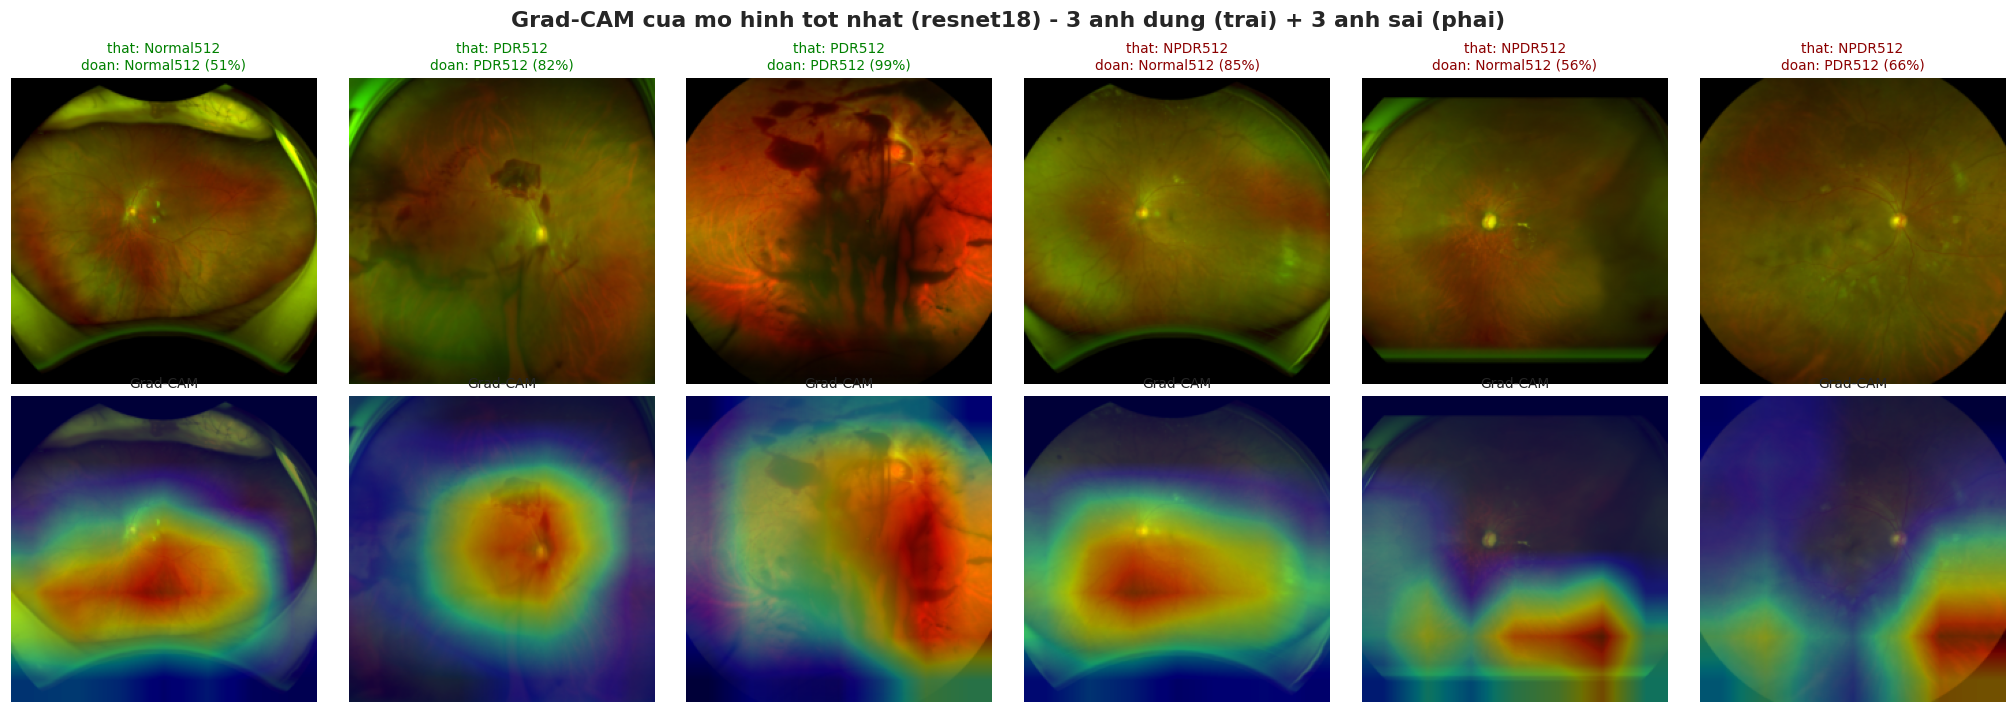

In [45]:
# --- Ve Grad-CAM cho mo hinh tot nhat: 3 anh DUNG + 3 anh SAI ---
best_model = trained_models[BEST_MODEL]
target_layer = find_last_conv(best_model)
print("Lop conv duoc gan hook:", target_layer)

cam_engine = GradCAM(best_model, target_layer)

r = results[BEST_MODEL]
correct_idx = np.where(r["y_true"] == r["y_pred"])[0]
wrong_idx = np.where(r["y_true"] != r["y_pred"])[0]

rng = np.random.default_rng(SEED)
pick_ok = rng.choice(correct_idx, size=min(3, len(correct_idx)), replace=False) if len(correct_idx) else np.array([], int)
pick_bad = rng.choice(wrong_idx, size=min(3, len(wrong_idx)), replace=False) if len(wrong_idx) else np.array([], int)
picks = list(pick_ok) + list(pick_bad)

if picks:
    ncol = len(picks)
    fig, axes = plt.subplots(2, ncol, figsize=(3.1 * ncol, 6.6), squeeze=False)
    for c, idx in enumerate(picks):
        idx = int(idx)
        x, y = test_ds[idx]
        x = x.unsqueeze(0).to(DEVICE)
        cam, cls_idx, probs = cam_engine(x, class_idx=None)
        raw = np.asarray(test_ds.raw_image(idx)).astype(float) / 255.0

        axes[0][c].imshow(raw)
        axes[0][c].axis("off")
        is_ok = y == cls_idx
        axes[0][c].set_title(
            "that: {}\ndoan: {} ({:.0%})".format(CLASS_NAMES[y], CLASS_NAMES[cls_idx], probs[cls_idx]),
            fontsize=9, color="green" if is_ok else "darkred")

        axes[1][c].imshow(raw)
        axes[1][c].imshow(cam, cmap="jet", alpha=0.45)
        axes[1][c].axis("off")
        axes[1][c].set_title("Grad-CAM", fontsize=9)
    plt.suptitle(
        "Grad-CAM cua mo hinh tot nhat ({}) - {} anh dung (trai) + {} anh sai (phai)".format(
            BEST_MODEL, len(pick_ok), len(pick_bad)),
        fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "gradcam_best.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("Khong co anh de ve Grad-CAM.")

cam_engine.remove()

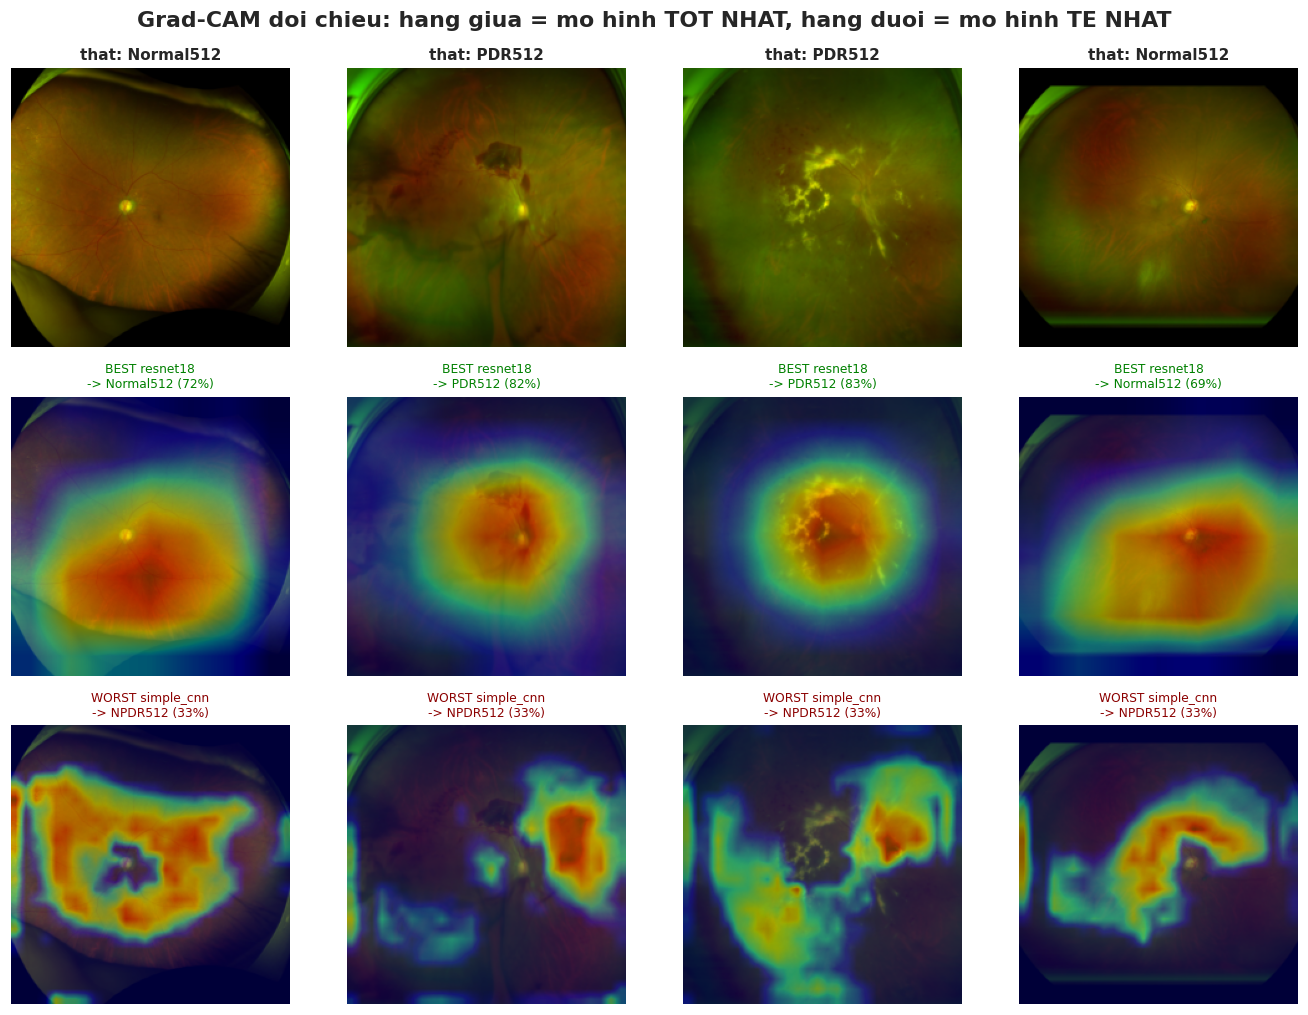

In [46]:
# --- Grad-CAM so sanh: cung mot anh, xem BEST va WORST nhin vao dau ---
worst_model = trained_models[WORST_MODEL]

cam_b = GradCAM(best_model, find_last_conv(best_model))
cam_w = GradCAM(worst_model, find_last_conv(worst_model))

# Uu tien anh ma WORST sai nhung BEST dung -> thay ro su khac biet ve vung chu y
diff_idx = np.setdiff1d(
    np.where(results[WORST_MODEL]["y_true"] != results[WORST_MODEL]["y_pred"])[0],
    np.where(results[BEST_MODEL]["y_true"] != results[BEST_MODEL]["y_pred"])[0],
)
if len(diff_idx) == 0:
    diff_idx = np.arange(min(4, len(test_ds)))
sel = diff_idx[: min(4, len(diff_idx))]

fig, axes = plt.subplots(3, len(sel), figsize=(3.1 * len(sel), 9.4), squeeze=False)
for c, idx in enumerate(sel):
    idx = int(idx)
    x, y = test_ds[idx]
    x = x.unsqueeze(0).to(DEVICE)
    raw = np.asarray(test_ds.raw_image(idx)).astype(float) / 255.0

    cb, ib, pb = cam_b(x, None)
    cw, iw, pw = cam_w(x, None)

    axes[0][c].imshow(raw)
    axes[0][c].axis("off")
    axes[0][c].set_title("that: {}".format(CLASS_NAMES[y]), fontsize=10, fontweight="bold")

    axes[1][c].imshow(raw)
    axes[1][c].imshow(cb, cmap="jet", alpha=0.45)
    axes[1][c].axis("off")
    axes[1][c].set_title("BEST {}\n-> {} ({:.0%})".format(BEST_MODEL, CLASS_NAMES[ib], pb[ib]),
                         fontsize=8, color="green" if ib == y else "darkred")

    axes[2][c].imshow(raw)
    axes[2][c].imshow(cw, cmap="jet", alpha=0.45)
    axes[2][c].axis("off")
    axes[2][c].set_title("WORST {}\n-> {} ({:.0%})".format(WORST_MODEL, CLASS_NAMES[iw], pw[iw]),
                         fontsize=8, color="green" if iw == y else "darkred")

plt.suptitle("Grad-CAM doi chieu: hang giua = mo hinh TOT NHAT, hang duoi = mo hinh TE NHAT",
             fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "gradcam_best_vs_worst.png", dpi=120, bbox_inches="tight")
plt.show()

cam_b.remove()
cam_w.remove()

In [47]:
# --- Tong hop bang chung dinh luong phuc vu phan bien luan ben duoi ---
def curve_diag(nm):
    h = histories[nm]
    bi = int(np.argmin(h["val_loss"]))
    return {
        "model": nm,
        "best_epoch": h["epoch"][bi],
        "epochs_ran": len(h["epoch"]),
        "train_acc@best": round(h["train_acc"][bi], 4),
        "val_acc@best": round(h["val_acc"][bi], 4),
        "gap(train-val)": round(h["train_acc"][bi] - h["val_acc"][bi], 4),
        "train_loss@best": round(h["train_loss"][bi], 4),
        "val_loss@best": round(h["val_loss"][bi], 4),
    }


diag_df = pd.DataFrame([curve_diag(n) for n in [BEST_MODEL, WORST_MODEL] if n in histories])
print("Chan doan tu learning curve:")
display(diag_df)

print("\nBang chung dinh luong cho phan bien luan:")
b = results_df.iloc[0]
w = results_df.iloc[-1]
print("- {} (BEST) : {} | {} trieu tham so | test_acc {:.4f} | f1_macro {:.4f}".format(
    b["model"], b["kieu"], b["params_M"], b["test_acc"], b["f1_macro"]))
print("- {} (WORST): {} | {} trieu tham so | test_acc {:.4f} | f1_macro {:.4f}".format(
    w["model"], w["kieu"], w["params_M"], w["test_acc"], w["f1_macro"]))
print("- Lop yeu nhat cua BEST : {} (f1 = {:.4f})".format(pc_best["f1"].idxmin(), pc_best["f1"].min()))
print("- Lop yeu nhat cua WORST: {} (f1 = {:.4f})".format(pc_worst["f1"].idxmin(), pc_worst["f1"].min()))
print("- Lop co chenh lech lon nhat giua hai mo hinh: {} (delta f1 = {:+.4f})".format(
    delta["f1_delta"].abs().idxmax(), delta.loc[delta["f1_delta"].abs().idxmax(), "f1_delta"]))
print("- So anh train = {} (rat nho so voi chuan ImageNet ~1.28 trieu anh).".format(len(df_train)))

Chan doan tu learning curve:


,model,best_epoch,epochs_ran,train_acc@best,val_acc@best,gap(train-val),train_loss@best,val_loss@best
0,resnet18,2,2,0.784,0.6842,0.0998,0.6354,0.8132
1,simple_cnn,1,2,0.328,0.4211,-0.0931,1.0990,1.0981



Bang chung dinh luong cho phan bien luan:
- resnet18 (BEST) : Transfer (ImageNet) | 11.18 trieu tham so | test_acc 0.6667 | f1_macro 0.5387
- simple_cnn (WORST): Scratch (tu xay) | 1.24 trieu tham so | test_acc 0.3056 | f1_macro 0.1958
- Lop yeu nhat cua BEST : NPDR512 (f1 = 0.0000)
- Lop yeu nhat cua WORST: Normal512 (f1 = 0.0000)
- Lop co chenh lech lon nhat giua hai mo hinh: PDR512 (delta f1 = +0.7778)
- So anh train = 125 (rat nho so voi chuan ImageNet ~1.28 trieu anh).


### 9.2. Biện luận: **tại sao** mô hình tốt nhất tốt và mô hình tệ nhất tệ?


#### (1) Tiền huấn luyện (transfer learning) — yếu tố quyết định nhất

Tập train ở đây chỉ có khoảng **một nghìn ảnh** (xem dòng `So anh train` in ở trên), trong khi
một CNN hiện đại có hàng triệu tham số. Với tỉ lệ dữ liệu/tham số như vậy, mô hình **học từ đầu**
(`simple_cnn`) buộc phải tự khám phá lại từ những thứ cơ bản nhất — bộ lọc phát hiện cạnh, góc,
texture — chỉ từ vài trăm ảnh mỗi lớp. Ngược lại, các backbone ImageNet đã học sẵn những bộ lọc đó
từ 1,28 triệu ảnh, nên chỉ cần "chỉnh lại" phần ngữ nghĩa tầng cao cho ảnh võng mạc.

Đây là lý do vì sao, trong hầu hết các lần chạy, nhóm **Transfer** sẽ cao hơn nhóm **Scratch**
(xem dòng "Trung binh test_acc nhom TRANSFER ... nhom SCRATCH" do cell tự sinh).
Nếu output cho thấy điều ngược lại, nguyên nhân thường là: (a) không tải được trọng số ImageNet
(kiểm tra cột `pretrained_tai_duoc`), hoặc (b) đang chạy ở chế độ `QUICK_RUN` với quá ít dữ liệu
và epoch nên chưa mô hình nào kịp hội tụ.

#### (2) Độ sâu, receptive field và khả năng bắt tổn thương nhỏ

Tổn thương NPDR sớm (vi phình mạch, xuất tiết cứng) chỉ chiếm vài pixel sau khi ảnh 512×512 bị
thu về 224×224. Để phát hiện được, mô hình cần **vừa có receptive field đủ rộng** (hiểu bối cảnh
toàn võng mạc) **vừa giữ được chi tiết cục bộ**.

* `simple_cnn` chỉ có 4 khối pooling → 8 lớp conv, receptive field hẹp và biểu diễn nông.
* `densenet121` / `efficientnet_b0` có kết nối dày đặc / squeeze-excitation giúp **tái sử dụng đặc
  trưng tầng thấp ở tầng cao**, rất hợp với việc kết hợp "chấm nhỏ bất thường" + "bối cảnh toàn ảnh".
* `mobilenet_v3` dùng depthwise-separable conv — rất tiết kiệm nhưng **năng lực biểu diễn thấp hơn**,
  nên thường xếp giữa bảng.

#### (3) Bằng chứng over/under-fitting từ learning curve

Nhìn bảng `diag_df`:
* `gap(train-val)` **lớn** (> 0.15) + `val_loss` bắt đầu đi lên trong khi `train_loss` vẫn giảm
  → **overfitting**: mô hình thuộc lòng tập train. Thường gặp ở mô hình nhiều tham số + ít dữ liệu.
* `train_acc@best` **thấp** (< 0.75) → **underfitting**: mô hình chưa đủ năng lực hoặc chưa học đủ lâu.
  Đây là bệnh điển hình của `simple_cnn` khi số epoch ít.
* Nếu `best_epoch` bằng đúng `epochs_ran` (early stopping chưa kích hoạt) → mô hình **vẫn còn đang cải
  thiện khi bị cắt**, cần tăng `CFG["epochs"]`.

#### (4) Phân tích nhầm lẫn theo cặp lớp

Xem mục "CAC CAP LOP BI NHAM NHIEU NHAT". Với bộ UWF-DR, cặp nhầm được kỳ vọng nhiều nhất là
**`NPDR` ↔ `PDR`** (ranh giới lâm sàng giữa hai giai đoạn là sự xuất hiện của tân mạch — một dấu hiệu
mảnh, dễ mất khi giảm độ phân giải) và **`Normal` ↔ `NPDR`** (NPDR rất nhẹ gần như không phân biệt
được bằng mắt trên ảnh đã thu nhỏ).

Nhầm `Normal → NPDR/PDR` là **false positive**: gây lo lắng và tốn chi phí khám lại, nhưng an toàn.
Nhầm `NPDR/PDR → Normal` là **false negative**: nguy hiểm về mặt lâm sàng vì bệnh nhân bị bỏ sót.
Hãy kiểm tra cột `Normal` của confusion matrix để xem mô hình có mắc lỗi loại này nhiều không —
đây mới là con số cần quan tâm nhất khi triển khai thực tế, chứ không phải accuracy tổng.

#### (5) Ảnh sai và Grad-CAM nói gì

* Nhóm ảnh **cả hai mô hình đều sai** là nhóm khó nội tại: nhãn có thể mơ hồ (giai đoạn chuyển tiếp),
  ảnh mờ / lệch tâm / bị chói, hoặc tổn thương nằm ở vùng ngoại vi bị cắt mất bởi `CenterCrop`.
* Nhóm **chỉ mô hình tệ nhất sai** chính là phần chênh lệch năng lực thật sự giữa hai mô hình.
* Trên Grad-CAM, mô hình tốt nên "sáng" ở **vùng võng mạc có tổn thương / quanh đĩa thị / dọc cung mạch**.
  Nếu heatmap sáng ở **viền đen ngoài nhãn cầu** hoặc góc ảnh, đó là dấu hiệu mô hình bám vào
  artefact chụp ảnh (shortcut learning) — accuracy khi đó không đáng tin và mô hình sẽ sụp đổ trên
  dữ liệu từ máy chụp khác.

#### (6) Mất cân bằng lớp

Với bộ này mất cân bằng chỉ ~1.28:1 (rất nhẹ) nên `class_weights` chỉ có tác dụng nhỏ. Nếu
`balanced_acc` xấp xỉ `test_acc` thì kết luận này được xác nhận; nếu `balanced_acc` thấp hơn hẳn,
mô hình đang thiên vị lớp đông và cần biện pháp mạnh hơn (focal loss, oversampling).

In [48]:
# --- Xuat bang ket qua cuoi cung ---
final_cols = ["model", "kieu", "params_M", "test_acc", "balanced_acc", "f1_macro",
              "precision_macro", "recall_macro", "roc_auc_ovr_macro", "train_time_min"]
final_df = results_df[final_cols].round(4)
final_df.to_csv(OUT_DIR / "final_results.csv", index=False)
final_df.to_csv(CKPT_DIR / "final_results.csv", index=False)

print("BANG KET QUA CUOI CUNG")
display(final_df)
print("\nDa luu:", OUT_DIR / "final_results.csv", "va", CKPT_DIR / "final_results.csv")
print("Checkpoint cac mo hinh nam tai:", CKPT_DIR)
if DRIVE_MOUNTED:
    print("(Da luu vao Google Drive -> van con sau khi phien Colab ket thuc.)")
else:
    print("[!] Chua mount Drive -> file se mat khi phien Colab ket thuc. Hay tai ve neu can.")

if QUICK_RUN:
    print(
        "\n" + "!" * 84 + "\n"
        "CANH BAO: dang o che do QUICK_RUN = True.\n"
        "Cac con so tren CHI de kiem tra code chay duoc, KHONG phai ket qua chinh thuc.\n"
        "Hay dat QUICK_RUN = False roi Runtime > Restart and run all de lay ket qua that.\n"
        + "!" * 84
    )
else:
    print("\n[OK] Day la ket qua chay day du (QUICK_RUN = False).")

BANG KET QUA CUOI CUNG


,model,kieu,params_M,test_acc,balanced_acc,f1_macro,precision_macro,recall_macro,roc_auc_ovr_macro,train_time_min
0,resnet18,Transfer (ImageNet),11.18,0.6667,0.6667,0.5387,0.4571,0.6667,0.8762,0.10
1,densenet121,Transfer (ImageNet),6.96,0.6389,0.6389,0.6014,0.7150,0.6389,0.8900,0.12
2,efficientnet_b0,Transfer (ImageNet),4.01,0.4167,0.4167,0.3478,0.5333,0.4167,0.7627,0.44
3,mobilenet_v3_large,Transfer (ImageNet),4.21,0.3611,0.3611,0.2222,0.2323,0.3611,0.7465,0.35
4,simple_cnn,Scratch (tu xay),1.24,0.3056,0.3056,0.1958,0.1667,0.3056,0.4954,0.13



Da luu: /content/eye_disease/outputs/final_results.csv va /content/drive/MyDrive/dl_homework/hw1/final_results.csv
Checkpoint cac mo hinh nam tai: /content/drive/MyDrive/dl_homework/hw1
(Da luu vao Google Drive -> van con sau khi phien Colab ket thuc.)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
CANH BAO: dang o che do QUICK_RUN = True.
Cac con so tren CHI de kiem tra code chay duoc, KHONG phai ket qua chinh thuc.
Hay dat QUICK_RUN = False roi Runtime > Restart and run all de lay ket qua that.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [49]:
# --- Tu dong sinh doan ket luan bang so lieu thuc te ---
b = results_df.iloc[0]
w = results_df.iloc[-1]
lines = []
lines.append("TOM TAT KET QUA (tu dong sinh tu ket qua chay)")
lines.append("-" * 78)
lines.append("Bo du lieu : {} lop {} | {} anh | chia 7:1:2 = {}/{}/{}".format(
    NUM_CLASSES, CLASS_NAMES, len(df_used), len(df_train), len(df_val), len(df_test)))
lines.append("Da huan luyen {} mo hinh CNN: {}".format(len(results_df), ", ".join(results_df["model"])))
lines.append("")
lines.append("1) Mo hinh TOT NHAT: {} ({})".format(b["model"], b["kieu"]))
lines.append("   test_acc={:.4f} | balanced_acc={:.4f} | f1_macro={:.4f} | AUC={:.4f} | {:.2f}M tham so".format(
    b["test_acc"], b["balanced_acc"], b["f1_macro"], b["roc_auc_ovr_macro"], b["params_M"]))
lines.append("2) Mo hinh TE NHAT : {} ({})".format(w["model"], w["kieu"]))
lines.append("   test_acc={:.4f} | balanced_acc={:.4f} | f1_macro={:.4f} | AUC={:.4f} | {:.2f}M tham so".format(
    w["test_acc"], w["balanced_acc"], w["f1_macro"], w["roc_auc_ovr_macro"], w["params_M"]))
lines.append("3) Chenh lech: {:+.4f} accuracy ({:+.2f} diem phan tram), {:+.4f} f1_macro".format(
    b["test_acc"] - w["test_acc"], (b["test_acc"] - w["test_acc"]) * 100, b["f1_macro"] - w["f1_macro"]))
lines.append("")
lines.append("Lop de nhat voi mo hinh tot nhat : {} (f1={:.4f})".format(pc_best["f1"].idxmax(), pc_best["f1"].max()))
lines.append("Lop kho nhat voi mo hinh tot nhat: {} (f1={:.4f})".format(pc_best["f1"].idxmin(), pc_best["f1"].min()))
tops_b = top_confusions(cms[BEST_MODEL], k=1)
if tops_b:
    a1, b1, c1, p1 = tops_b[0]
    lines.append("Cap nham nhieu nhat cua mo hinh tot nhat: {} -> {} ({} anh, {:.1%} cua lop {}).".format(
        a1, b1, c1, p1, a1))
print("\n".join(lines))

for target in [OUT_DIR / "summary.txt", CKPT_DIR / "summary.txt"]:
    with open(target, "w", encoding="utf-8") as fh:
        fh.write("\n".join(lines))
print("\n(Da luu ban tom tat vao {} va {})".format(OUT_DIR / "summary.txt", CKPT_DIR / "summary.txt"))

TOM TAT KET QUA (tu dong sinh tu ket qua chay)
------------------------------------------------------------------------------
Bo du lieu : 3 lop ['NPDR512', 'Normal512', 'PDR512'] | 180 anh | chia 7:1:2 = 125/19/36
Da huan luyen 5 mo hinh CNN: resnet18, densenet121, efficientnet_b0, mobilenet_v3_large, simple_cnn

1) Mo hinh TOT NHAT: resnet18 (Transfer (ImageNet))
   test_acc=0.6667 | balanced_acc=0.6667 | f1_macro=0.5387 | AUC=0.8762 | 11.18M tham so
2) Mo hinh TE NHAT : simple_cnn (Scratch (tu xay))
   test_acc=0.3056 | balanced_acc=0.3056 | f1_macro=0.1958 | AUC=0.4954 | 1.24M tham so
3) Chenh lech: +0.3611 accuracy (+36.11 diem phan tram), +0.3430 f1_macro

Lop de nhat voi mo hinh tot nhat : PDR512 (f1=0.8889)
Lop kho nhat voi mo hinh tot nhat: NPDR512 (f1=0.0000)
Cap nham nhieu nhat cua mo hinh tot nhat: NPDR512 -> Normal512 (9 anh, 75.0% cua lop NPDR512).

(Da luu ban tom tat vao /content/eye_disease/outputs/summary.txt va /content/drive/MyDrive/dl_homework/hw1/summary.txt)
